### DUAL PATHWAY MODEL

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
import time

# Positional Encoding
class PositionalEncoding(nn.Module):
    """
    Positional encoding for transformer sequence data.
    Adds information about the position of each element in the sequence.
    """
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        # Initialize positional encoding buffer
        pe = torch.zeros(max_len, d_model)

        # Sine for even indices, cosine for odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer (not a parameter)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor, shape [batch_size, seq_len, embedding_dim]
        Returns:
            Tensor with positional encoding added, same shape as x
        """
        # Add positional encoding to input tensor
        x = x + self.pe[:x.size(1)]

        # Apply dropout
        return self.dropout(x)

class FeatureRouter(nn.Module):
    def __init__(self, input_dims, hidden_dim=32):
        super().__init__()
        self.mechanics_classifiers = nn.ModuleDict()
        self.force_classifiers = nn.ModuleDict()

        for name, dim in input_dims.items():
            # Create soft classification networks for each input type
            self.mechanics_classifiers[name] = nn.Sequential(
                nn.Linear(dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid()
            )
            self.force_classifiers[name] = nn.Sequential(
                nn.Linear(dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid()
            )

    def forward(self, input_sequences):
        mechanics_sequences = {}
        force_sequences = {}
        routing_weights = {}

        for name, sequence in input_sequences.items():
            # Get routing weights for this sequence type
            mechanics_weight = self.mechanics_classifiers[name](sequence)
            force_weight = self.force_classifiers[name](sequence)

            # Normalize weights to sum to 1
            total_weight = mechanics_weight + force_weight
            mechanics_weight = mechanics_weight / (total_weight + 1e-8)
            force_weight = force_weight / (total_weight + 1e-8)

            # Route features to each pathway with soft weights
            mechanics_sequences[name] = sequence * mechanics_weight
            force_sequences[name] = sequence * force_weight

            routing_weights[name] = {
                'mechanics': mechanics_weight.mean().item(),
                'force': force_weight.mean().item()
            }

        return mechanics_sequences, force_sequences, routing_weights

class PathwayEncoder(nn.Module):
    def __init__(self, input_dims, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_dims = input_dims

        # Create embeddings for each input type
        self.embeddings = nn.ModuleDict()
        for name, dim in input_dims.items():
            self.embeddings[name] = nn.Linear(dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Cross-modal attention
        self.cross_attn = nn.ModuleDict()
        for name in input_dims.keys():
            self.cross_attn[name] = nn.MultiheadAttention(
                embed_dim=d_model,
                num_heads=nhead,
                dropout=dropout,
                batch_first=True
            )

        # Transformer encoder for each type
        self.transformers = nn.ModuleDict()
        for name in input_dims.keys():
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model*2,
                dropout=dropout,
                batch_first=True
            )
            self.transformers[name] = nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )

        # Global fusion
        self.fusion = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, sequences):
        # Embed each sequence type
        embedded_sequences = {}
        for name, sequence in sequences.items():
            embedded = self.embeddings[name](sequence)
            embedded_sequences[name] = self.pos_encoder(embedded)

        # Cross-modal attention
        cross_attended = {}
        cross_attn_weights = {}

        for name, embedded in embedded_sequences.items():
            # Collect all other modalities
            other_modalities = []
            for other_name, other_embedded in embedded_sequences.items():
                if other_name != name:
                    other_modalities.append(other_embedded)

            if other_modalities:
                # Concatenate other modalities along sequence dimension
                other_combined = torch.cat(other_modalities, dim=1)

                # Apply cross-attention
                attended, attn_weights = self.cross_attn[name](
                    query=embedded,
                    key=other_combined,
                    value=other_combined
                )

                cross_attended[name] = attended
                cross_attn_weights[name] = attn_weights
            else:
                cross_attended[name] = embedded
                cross_attn_weights[name] = None

        # Apply transformer to each modality
        transformed = {}
        for name, attended in cross_attended.items():
            transformed[name] = self.transformers[name](attended)

        # Global fusion
        if len(transformed) > 0:
            # Stack all transformed features
            stacked = torch.stack(list(transformed.values()), dim=1)

            # Mean across motion types (simplification)
            fused = stacked.mean(dim=1)

            # Create a learnable query for global representation
            batch_size = fused.shape[0]
            global_query = torch.zeros(batch_size, 1, fused.shape[-1], device=fused.device)

            # Apply attention-based fusion
            global_features, fusion_weights = self.fusion(
                global_query,
                fused,
                fused
            )

            global_features = global_features.squeeze(1)
        else:
            global_features = None
            fusion_weights = None

        return global_features, transformed, {
            'cross_attn': cross_attn_weights,
            'fusion': fusion_weights
        }

class MechanicsAnalysisBranch(nn.Module):
    def __init__(self, d_model, num_phases=5):
        super().__init__()

        # Temporal convolutional layers for phase detection
        self.conv_layers = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU()
        )

        # Phase detection
        self.phase_detector = nn.Linear(d_model, num_phases)

        # Mechanics score
        self.mechanics_score = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, features):
        # Apply temporal convolution
        batch_size, seq_len, d_model = features.shape
        conv_input = features.transpose(1, 2)  # [batch, d_model, seq_len]
        conv_output = self.conv_layers(conv_input)
        conv_output = conv_output.transpose(1, 2)  # [batch, seq_len, d_model]

        # Phase detection
        phase_logits = self.phase_detector(conv_output)

        # Apply phase bias to encourage sequential transitions
        phase_bias = torch.zeros_like(phase_logits)
        num_phases = phase_bias.shape[-1]

        # Each phase is more likely in its expected time segment
        for i in range(num_phases):
            segment_start = int(seq_len * (i / num_phases))
            segment_end = int(seq_len * ((i + 1) / num_phases))
            phase_bias[:, segment_start:segment_end, i] = 2.0

        phase_logits = phase_logits + phase_bias
        phase_probs = F.softmax(phase_logits, dim=-1)

        # Mechanics score (average across sequence)
        pooled_features = features.mean(dim=1)
        mechanics_score = self.mechanics_score(pooled_features)

        return mechanics_score, phase_probs, pooled_features

class ForceAnalysisBranch(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        # Force peak detection
        self.peak_detector = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(d_model, 1, kernel_size=1)
        )

        # Force score
        self.force_score = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, features):
        # Apply peak detection
        batch_size, seq_len, d_model = features.shape
        conv_input = features.transpose(1, 2)  # [batch, d_model, seq_len]
        peak_scores = self.peak_detector(conv_input)
        peak_scores = peak_scores.transpose(1, 2)  # [batch, seq_len, 1]

        # Force score (average across sequence)
        pooled_features = features.mean(dim=1)
        force_score = self.force_score(pooled_features)

        return force_score, peak_scores, pooled_features

class IntegrationLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        # Interaction modeling
        self.interaction = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )

        # Velocity prediction
        self.velocity_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, mechanics_features, force_features):
        # Concatenate mechanics and force features
        combined = torch.cat([mechanics_features, force_features], dim=1)

        # Model interactions
        interaction = self.interaction(combined)

        # Predict velocity
        velocity = self.velocity_head(interaction)

        return velocity, interaction

class DualPathwayPitchingModel(nn.Module):
    def __init__(self, input_dims, d_model=64, nhead=4, num_layers=2, dropout=0.1, max_seq_length=None):
        super().__init__()
        self.max_seq_length = max_seq_length

        # Feature router
        self.router = FeatureRouter(input_dims)

        # Mechanics pathway
        self.mechanics_encoder = PathwayEncoder(
            input_dims, d_model, nhead, num_layers, dropout
        )

        # Force pathway
        self.force_encoder = PathwayEncoder(
            input_dims, d_model, nhead, num_layers, dropout
        )

        # Mechanics analysis
        self.mechanics_analysis = MechanicsAnalysisBranch(d_model, num_phases=5)

        # Force analysis
        self.force_analysis = ForceAnalysisBranch(d_model)

        # Integration layer
        self.integration = IntegrationLayer(d_model)

    def forward(self, sequences, return_details=False):
        # Route features to each pathway
        mechanics_sequences, force_sequences, routing_weights = self.router(sequences)

        # Process each pathway
        mechanics_features, mechanics_transformed, mechanics_attn = self.mechanics_encoder(mechanics_sequences)
        force_features, force_transformed, force_attn = self.force_encoder(force_sequences)

        # Analyze mechanics
        if mechanics_transformed and len(mechanics_transformed) > 0:
            first_mechanics_key = list(mechanics_transformed.keys())[0]
            mechanics_score, phase_probs, pooled_mechanics = self.mechanics_analysis(
                mechanics_transformed[first_mechanics_key]
            )
        else:
            # Handle empty case
            batch_size = next(iter(sequences.values())).shape[0]
            mechanics_score = torch.zeros(batch_size, 1, device=next(iter(sequences.values())).device)
            phase_probs = torch.zeros(batch_size, seq_len, 5, device=next(iter(sequences.values())).device)

            pooled_mechanics = mechanics_features if mechanics_features is not None else torch.zeros(batch_size, 64, device=next(iter(sequences.values())).device)

        # Analyze force
        if force_transformed and len(force_transformed) > 0:
            first_force_key = list(force_transformed.keys())[0]
            force_score, peak_scores, pooled_force = self.force_analysis(
                force_transformed[first_force_key]
            )
        else:
            # Handle empty case
            batch_size = next(iter(sequences.values())).shape[0]
            force_score = torch.zeros(batch_size, 1, device=next(iter(sequences.values())).device)
            peak_scores = torch.zeros(batch_size, seq_len, 1, device=next(iter(sequences.values())).device)
            pooled_force = force_features if force_features is not None else torch.zeros(batch_size, 64, device=next(iter(sequences.values())).device)

        # Integration
        velocity, interaction = self.integration(pooled_mechanics, pooled_force)

        if return_details:
            return velocity, {
                'mechanics_score': mechanics_score,
                'force_score': force_score,
                'phase_probs': phase_probs,
                'peak_scores': peak_scores,
                'routing_weights': routing_weights,
                'mechanics_attn': mechanics_attn,
                'force_attn': force_attn
            }

        return velocity

# Dataset class
class EnhancedPitchingDataset(Dataset):
    def __init__(self, processed_pitches, max_seq_length=500):
        self.processed_pitches = processed_pitches
        self.max_seq_length = max_seq_length

        # Find all motion types
        all_motion_types = set()
        for pitch in processed_pitches:
            all_motion_types.update(pitch['sequences'].keys())
        self.motion_types = sorted(all_motion_types)

        # Calculate feature dimensions
        self.feature_dims = {}
        for mt in self.motion_types:
            for pitch in processed_pitches:
                if mt in pitch['sequences']:
                    self.feature_dims[mt] = pitch['sequences'][mt].shape[1]
                    break

        print(f"Dataset created with {len(processed_pitches)} pitches")
        print(f"Motion types: {self.motion_types}")
        print(f"Feature dimensions: {self.feature_dims}")

    def __len__(self):
        return len(self.processed_pitches)

    def __getitem__(self, idx):
        pitch = self.processed_pitches[idx]

        # Process each motion type separately
        sequences = {}
        masks = {}

        for mt in self.motion_types:
            if mt in pitch['sequences']:
                # Get sequence data
                sequence = pitch['sequences'][mt]

                # Handle sequence length
                seq_len = min(sequence.shape[0], self.max_seq_length)
                padded_sequence = np.zeros((self.max_seq_length, sequence.shape[1]))
                padded_sequence[:seq_len] = sequence[:seq_len]

                # Create mask (1 for real data, 0 for padding)
                mask = np.zeros(self.max_seq_length)
                mask[:seq_len] = 1

                # Add to dictionary
                sequences[mt] = padded_sequence
                masks[mt] = mask
            else:
                # Use dummy data for missing types
                if mt in self.feature_dims:
                    feature_dim = self.feature_dims[mt]
                    sequences[mt] = np.zeros((self.max_seq_length, feature_dim))
                    masks[mt] = np.zeros(self.max_seq_length)

        # Convert to tensors
        tensor_sequences = {
            mt: torch.FloatTensor(sequences[mt]) for mt in sequences
        }

        tensor_masks = {
            mt: torch.FloatTensor(masks[mt]) for mt in masks
        }

        return {
            'sequences': tensor_sequences,
            'masks': tensor_masks,
            'velocity': torch.FloatTensor([pitch['velocity']]),
            'pitch_id': pitch['pitch_id']
        }

# Data loading and preprocessing
def load_and_process_data(data_dir):
    """Load and preprocess pitching data from CSV files"""
    print(f"Loading data from {data_dir}")

    # Load POI metrics (contains velocity)
    poi_path = os.path.join(data_dir, 'poi_metrics.csv')
    poi_df = pd.read_csv(poi_path)
    print(f"Loaded POI data: {poi_df.shape}")

    # Load motion data files
    motion_data = {}
    for filename in ['energy_flow.csv', 'force_plate.csv', 'forces_moments.csv',
                    'joint_angles.csv', 'joint_velos.csv', 'landmarks.csv']:
        try:
            filepath = os.path.join(data_dir, filename)
            if os.path.exists(filepath):
                df = pd.read_csv(filepath)
                name = os.path.splitext(filename)[0]
                motion_data[name] = df
                print(f"Loaded {name}: {df.shape}")
        except Exception as e:
            print(f"Error loading {filename}: {e}")

    # Process data
    processed_pitches = preprocess_data(poi_df, motion_data)

    return processed_pitches

def preprocess_data(poi_df, motion_data, pitch_id_col='session_pitch', velocity_col='pitch_speed_mph'):
    """Preprocess pitching data"""
    processed_pitches = []

    # Get unique pitches with velocity data
    unique_pitches = poi_df[pitch_id_col].unique()
    print(f"Processing {len(unique_pitches)} unique pitches")

    for pitch_id in unique_pitches:
        try:
            # Get velocity
            pitch_row = poi_df[poi_df[pitch_id_col] == pitch_id]
            if pitch_row.empty:
                continue

            if velocity_col not in pitch_row.columns:
                print(f"ERROR: Velocity column '{velocity_col}' not found in columns: {pitch_row.columns}")
                continue

            velocity = float(pitch_row[velocity_col].values[0])

            # Skip pitches with invalid velocity
            if np.isnan(velocity) or velocity <= 0 or velocity > 120:
                print(f"Skipping pitch {pitch_id} with invalid velocity: {velocity}")
                continue

            # Process sequences
            sequences = {}

            for name, df in motion_data.items():
                # Get data for this pitch
                pitch_df = df[df[pitch_id_col] == pitch_id].copy()

                if pitch_df.empty:
                    continue

                # Keep only numeric columns except pitch_id
                numeric_cols = [col for col in pitch_df.columns
                               if pd.api.types.is_numeric_dtype(df[col])
                               and col != pitch_id_col]

                if not numeric_cols:
                    continue

                # Extract sequence and handle NaN values
                sequence = pitch_df[numeric_cols].values

                # Skip sequences with all NaN values in any column
                if np.isnan(sequence).all(axis=0).any():
                    continue

                # Replace remaining NaN values with 0
                sequence = np.nan_to_num(sequence, nan=0.0)

                # Normalize the sequence (simple min-max scaling per feature)
                for j in range(sequence.shape[1]):
                    col_min = sequence[:, j].min()
                    col_max = sequence[:, j].max()
                    if col_max > col_min:
                        sequence[:, j] = (sequence[:, j] - col_min) / (col_max - col_min)

                sequences[name] = sequence

            # Only keep pitches with motion data
            if sequences:
                processed_pitch = {
                    'pitch_id': pitch_id,
                    'velocity': velocity,
                    'sequences': sequences
                }
                processed_pitches.append(processed_pitch)

        except Exception as e:
            print(f"Error processing pitch {pitch_id}: {e}")

    print(f"Successfully processed {len(processed_pitches)} pitches")
    return processed_pitches

# Training function
def train_dual_pathway_model(model, train_loader, val_loader, epochs=50, lr=5e-5, device='cuda'):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Learning rate scheduler with OneCycleLR
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=2e-4,
        total_steps=epochs * len(train_loader),
        pct_start=0.1,  # 10% warmup
        div_factor=20,  # initial_lr = max_lr/div_factor
        final_div_factor=1000,  # final_lr = max_lr/final_div_factor
        anneal_strategy='cos'
    )

    # Loss functions
    mse_loss = nn.MSELoss()

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    patience = 10
    patience_counter = 0

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        batch_count = 0

        for batch in train_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            velocity = batch['velocity'].to(device)

            # Forward pass
            optimizer.zero_grad()

            # Get predictions and details
            outputs = model(sequences, return_details=True)
            pred_velocity, details = outputs

            # Calculate losses
            # 1. Velocity prediction loss
            velocity_loss = mse_loss(pred_velocity, velocity)

            # 2. Entropy loss for phases to be more decisive
            phase_probs = details['phase_probs']
            entropy_loss = -(phase_probs * torch.log(phase_probs + 1e-10)).sum(dim=-1).mean()

            # In your training loop, modify the correlation loss part:

            # 3. Mechanics-force correlation loss
            mechanics_score = details['mechanics_score']
            force_score = details['force_score']

            # Calculate expected negative correlation
            # Fix the tensor shape mismatch
            target_corr = torch.tensor([[-0.3]], device=device)  # Shape [1,1]
            actual_corr = F.cosine_similarity(mechanics_score - 0.5, force_score - 0.5, dim=0).reshape(1, 1)  # Ensure shape [1,1]
            corr_loss = F.mse_loss(actual_corr, target_corr)

            # Combined loss
            loss = velocity_loss + 0.1 * entropy_loss + 0.05 * corr_loss

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights
            optimizer.step()

            # Step the scheduler (per batch)
            scheduler.step()

            # Track losses
            epoch_loss += velocity_loss.item()
            batch_count += 1

        # Calculate average loss
        avg_train_loss = epoch_loss / batch_count
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_batch_count = 0

        with torch.no_grad():
            for batch in val_loader:
                # Get data
                sequences = {
                    mt: batch['sequences'][mt].to(device)
                    for mt in batch['sequences']
                }
                velocity = batch['velocity'].to(device)

                # Forward pass
                pred_velocity = model(sequences)

                # Calculate loss
                loss = mse_loss(pred_velocity, velocity)

                val_loss += loss.item()
                val_batch_count += 1

        # Calculate average validation loss
        avg_val_loss = val_loss / val_batch_count
        val_losses.append(avg_val_loss)

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Check if this is the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
            patience_counter = 0
            print(f"  New best model with val loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Save the best model
    if best_model_state is not None:
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': best_model_state,
            'val_loss': best_val_loss,
        }, 'best_dual_pathway_model.pt')
        print(f"Saved best model from epoch {best_epoch+1} with val loss: {best_val_loss:.4f}")

    return train_losses, val_losses, best_epoch

# Visualization function
def analyze_pitcher_development(model, test_dataset, device='cpu'):
    """Analyze pitchers using the dual-pathway model and create the development matrix"""
    model = model.to(device)
    model.eval()

    mechanics_scores = []
    force_scores = []
    velocities = []
    pitch_ids = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            sample = test_dataset[i]

            # Prepare input
            sequences = {
                mt: sample['sequences'][mt].unsqueeze(0).to(device)
                for mt in sample['sequences']
            }

            # Get predictions and details
            velocity, details = model(sequences, return_details=True)

            # Extract scores
            mechanics_score = details['mechanics_score'].item()
            force_score = details['force_score'].item()

            # Store results
            mechanics_scores.append(mechanics_score)
            force_scores.append(force_score)
            velocities.append(sample['velocity'].item())
            pitch_ids.append(sample['pitch_id'])

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores,
        'velocity': velocities
    })

    # Create mechanics categories
    results['mechanics_category'] = pd.cut(
        results['mechanics_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Poor', 'Developing', 'Efficient']
    )

    # Create force categories
    results['force_category'] = pd.cut(
        results['force_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Low', 'Medium', 'High']
    )

    # Create development quadrants
    results['development_quadrant'] = results.apply(
        lambda row: f"{row['mechanics_category']}/{row['force_category']}",
        axis=1
    )

    # Create visualization
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        results['mechanics_score'],
        results['force_score'],
        c=results['velocity'],
        cmap='viridis',
        alpha=0.7,
        s=50
    )

    plt.colorbar(scatter, label='Velocity (mph)')
    plt.xlabel('Mechanics Score')
    plt.ylabel('Force Generation Score')
    plt.title('Pitcher Development Matrix')

    # Add quadrant lines
    plt.axvline(x=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)

    # Add quadrant labels
    plt.text(0.2, 0.2, "Poor Mechanics\nLow Force\n(Full Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.55, "Poor Mechanics\nMedium Force\n(Technical Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.85, "Poor Mechanics\nHigh Force\n(Mechanics Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=.05))

    plt.text(0.55, 0.2, "Developing Mechanics\nLow Force\n(Strength Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.55, "Developing Mechanics\nMedium Force\n(Balanced Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.85, "Developing Mechanics\nHigh Force\n(Fine-tune Mechanics)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.85, 0.2, "Efficient Mechanics\nLow Force\n(Force Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.55, "Efficient Mechanics\nMedium Force\n(Power Training)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.85, "Efficient Mechanics\nHigh Force\n(Optimized)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.savefig('development_matrix.png')

    return results, plt.gcf()

def main():
    # Set parameters
    data_dir = "/content"  # Update with your data path
    max_seq_length = 500   # Maintain this for full sequence analysis
    batch_size = 8        # Use original batch size since memory is no longer an issue
    epochs = 150
    learning_rate = 5e-5   # Changed from 1e-4

    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    # Create output directory
    os.makedirs("dual_pathway_results", exist_ok=True)

    # Load and process data
    processed_pitches = load_and_process_data(data_dir)

    # Split data
    train_data, temp_data = train_test_split(processed_pitches, test_size=0.3, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)
    print(f"Data split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

    # Create datasets
    train_dataset = EnhancedPitchingDataset(train_data, max_seq_length=max_seq_length)
    val_dataset = EnhancedPitchingDataset(val_data, max_seq_length=max_seq_length)
    test_dataset = EnhancedPitchingDataset(test_data, max_seq_length=max_seq_length)

    # Create dataloaders with more efficient loading
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True    # Faster data transfer to GPU
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        pin_memory=True
    )

    # Get input dimensions for model
    input_dims = train_dataset.feature_dims

    model = DualPathwayPitchingModel(
        input_dims=input_dims,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.2,
        max_seq_length=max_seq_length  # The value from your dataset
    )

    # Print model parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model has {total_params:,} parameters")

    # Choose device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Train model
    print("Starting training...")
    train_losses, val_losses, best_epoch = train_dual_pathway_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=learning_rate,
        device=device
    )

    # Rest of your main function remains the same
    # ...

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Model (Epoch {best_epoch+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('dual_pathway_results/training_curve.png')
    plt.close()

    # Load best model for evaluation
    checkpoint = torch.load('best_dual_pathway_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Evaluate on test set
    print("Evaluating on test set...")
    test_loss = 0
    predictions = []
    actuals = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            velocity = batch['velocity'].to(device)

            # Forward pass
            pred_velocity = model(sequences)

            # Calculate loss
            loss = nn.MSELoss()(pred_velocity, velocity)
            test_loss += loss.item() * len(velocity)

            # Store predictions and actuals
            predictions.extend(pred_velocity.cpu().numpy().flatten())
            actuals.extend(velocity.cpu().numpy().flatten())

    # Calculate test metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    test_loss = test_loss / len(test_dataset)
    test_rmse = np.sqrt(mean_squared_error(actuals, predictions))
    test_mae = mean_absolute_error(actuals, predictions)
    test_r2 = r2_score(actuals, predictions)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test R²: {test_r2:.4f}")

    # Create prediction vs actual plot
    plt.figure(figsize=(10, 8))
    plt.scatter(actuals, predictions, alpha=0.7)
    plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--', label='Perfect Prediction')

    # Add trendline
    z = np.polyfit(actuals, predictions, 1)
    p = np.poly1d(z)
    plt.plot(
        np.sort(actuals),
        p(np.sort(actuals)),
        'g-',
        label=f'Trend Line (y = {z[0]:.2f}x + {z[1]:.2f})'
    )

    plt.xlabel('Actual Velocity (mph)')
    plt.ylabel('Predicted Velocity (mph)')
    plt.title('Predicted vs Actual Velocity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('dual_pathway_results/predicted_vs_actual.png')
    plt.close()

    # Create development matrix analysis
    print("Creating development matrix analysis...")
    results, matrix_fig = analyze_pitcher_development(model, test_dataset, device)
    matrix_fig.savefig('dual_pathway_results/development_matrix.png')
    plt.close(matrix_fig)

    # Save development matrix results
    results.to_csv('dual_pathway_results/development_results.csv', index=False)

    # Create distribution plots for mechanics and force scores
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(results['mechanics_score'], bins=15, alpha=0.7, color='blue')
    plt.xlabel('Mechanics Score')
    plt.ylabel('Number of Pitches')
    plt.title('Distribution of Mechanics Scores')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(results['force_score'], bins=15, alpha=0.7, color='orange')
    plt.xlabel('Force Generation Score')
    plt.ylabel('Number of Pitches')
    plt.title('Distribution of Force Generation Scores')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('dual_pathway_results/score_distributions.png')
    plt.close()

    # Create correlation heatmap
    plt.figure(figsize=(8, 6))
    corr = results[['mechanics_score', 'force_score', 'velocity']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
    plt.title('Correlation Between Metrics')
    plt.tight_layout()
    plt.savefig('dual_pathway_results/correlation_heatmap.png')
    plt.close()

    print("\nTraining and evaluation complete!")
    print("Results saved in 'dual_pathway_results' directory")

    # Save test pitch IDs for future analysis
    with open('dual_pathway_results/test_pitch_ids.txt', 'w') as f:
        for pitch_id in results['pitch_id']:
            f.write(f"{pitch_id}\n")


if __name__ == "__main__":
    main()



Loading data from /content
Loaded POI data: (411, 81)
Loaded energy_flow: (247709, 54)
Loaded force_plate: (727824, 15)
Loaded forces_moments: (247709, 104)
Loaded joint_angles: (247709, 53)
Loaded joint_velos: (247709, 47)
Loaded landmarks: (247709, 62)
Processing 411 unique pitches
Successfully processed 403 pitches
Data split: Train=282, Val=60, Test=61
Dataset created with 282 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
Dataset created with 60 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
Dataset created with 61 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Feature dimensions: {'energy_f

### Performance Plots

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
from torch.utils.data import DataLoader

def evaluate_model_and_create_plot(model_path, test_dataset, batch_size=8, device='cuda', save_path='predicted_vs_actual_poster.png'):
    """
    Load a trained model, evaluate it on test data, and create a publication-quality scatter plot

    Args:
        model_path: Path to the saved model checkpoint
        test_dataset: EnhancedPitchingDataset with test data
        batch_size: Batch size for evaluation
        device: Device to run evaluation on ('cuda' or 'cpu')
        save_path: Path to save the resulting plot
    """
    # Create test dataloader
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    device = torch.device(device if torch.cuda.is_available() else 'cpu')

    # Load the trained model
    checkpoint = torch.load(model_path, map_location=device)

    # Get input dimensions from the dataset
    input_dims = test_dataset.feature_dims



    # Create model with same architecture as during training
    model = DualPathwayPitchingModel(
        input_dims=input_dims,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.2
    )

    # Load the saved state
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Collect predictions and actual values
    predictions = []
    actuals = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            velocity = batch['velocity'].to(device)

            # Forward pass
            pred_velocity = model(sequences)

            # Store predictions and actuals
            predictions.extend(pred_velocity.cpu().numpy().flatten())
            actuals.extend(velocity.cpu().numpy().flatten())

    # Create the plot
    create_performance_plot(predictions, actuals, save_path)

    # Return metrics
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': predictions,
        'actuals': actuals
    }

def create_performance_plot(predictions, actuals, save_path='predicted_vs_actual_poster.png'):
    """
    Create a publication-quality scatter plot of predicted vs actual values
    with performance metrics.
    """
    # Convert to numpy arrays if they aren't already
    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    # Create figure with high resolution
    plt.figure(figsize=(12, 10), dpi=300)

    # Set font sizes
    TITLE_SIZE = 24
    AXIS_LABEL_SIZE = 20
    TICK_SIZE = 16
    LEGEND_SIZE = 16
    ANNOTATION_SIZE = 18

    # Create a scatter plot
    plt.scatter(actuals, predictions, alpha=0.7, s=100, color='#2c7fb8', edgecolor='#252525', linewidth=0.5)

    # Plot the perfect prediction line
    min_val = min(min(actuals), min(predictions))
    max_val = max(max(actuals), max(predictions))

    # Add some padding to the limits
    range_val = max_val - min_val
    min_val -= range_val * 0.20
    max_val += range_val * 0.20

    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    # Add trendline
    z = np.polyfit(actuals, predictions, 1)
    p = np.poly1d(z)
    plt.plot(
        np.sort(actuals),
        p(np.sort(actuals)),
        'g-',
        linewidth=2,
        label=f'Trend Line (y = {z[0]:.2f}x + {z[1]:.2f})'
    )

    # Add performance metrics
    metrics_text = f'RMSE: {rmse:.2f} mph\nMAE: {mae:.2f} mph\nR²: {r2:.3f}'
    plt.annotate(
        metrics_text,
        xy=(0.05, 0.80),
        xycoords='axes fraction',
        fontsize=ANNOTATION_SIZE,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.8, edgecolor='#666666')
    )

    # Set labels and title
    plt.xlabel('Actual Velocity (mph)', fontsize=AXIS_LABEL_SIZE, fontweight='bold')
    plt.ylabel('Predicted Velocity (mph)', fontsize=AXIS_LABEL_SIZE, fontweight='bold')
    plt.title('Dual-Pathway Model Performance', fontsize=TITLE_SIZE, fontweight='bold', pad=20)

    # Set ticks
    plt.xticks(fontsize=TICK_SIZE)
    plt.yticks(fontsize=TICK_SIZE)



    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')

    # Set equal aspect ratio
    plt.axis('equal')
    plt.tight_layout()

    # Save figure
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Plot saved to {save_path}")

    return plt.gcf()


    # Assuming you've already run the main training code
    # and have test_dataset defined

    # First make sure we have our test dataset
import os
import numpy as np
from sklearn.model_selection import train_test_split



# Set paths and parameters
data_dir = "/content"  # Update with your data path
max_seq_length = 500
model_path = 'best_dual_pathway_model.pt'  # Path to your saved model

# Create output directory
os.makedirs("dual_pathway_results", exist_ok=True)

# Load and process data
print("Loading and processing data...")
processed_pitches = load_and_process_data(data_dir)

# Split data
train_data, temp_data = train_test_split(processed_pitches, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)
print(f"Data split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

# Create test dataset
test_dataset = EnhancedPitchingDataset(test_data, max_seq_length=max_seq_length)

# Evaluate and create plot
print("Evaluating model and creating plot...")
results = evaluate_model_and_create_plot(
    model_path=model_path,
    test_dataset=test_dataset,
    batch_size=8,
    device='cuda',
    save_path='dual_pathway_results/predicted_vs_actual_poster.png'
)

# Print metrics
print(f"Test RMSE: {results['rmse']:.4f}")
print(f"Test MAE: {results['mae']:.4f}")
print(f"Test R²: {results['r2']:.4f}")
print(f"Plot saved to dual_pathway_results/predicted_vs_actual_poster.png")

Loading and processing data...
Loading data from /content
Loaded POI data: (411, 81)
Loaded energy_flow: (247709, 54)
Loaded force_plate: (727824, 15)
Loaded forces_moments: (247709, 104)
Loaded joint_angles: (247709, 53)
Loaded joint_velos: (247709, 47)
Loaded landmarks: (247709, 62)
Processing 411 unique pitches
Successfully processed 403 pitches
Data split: Train=282, Val=60, Test=61
Dataset created with 61 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
Evaluating model and creating plot...


RuntimeError: Error(s) in loading state_dict for DualPathwayPitchingModel:
	Unexpected key(s) in state_dict: "router.mechanics_classifiers.force_plate.0.weight", "router.mechanics_classifiers.force_plate.0.bias", "router.mechanics_classifiers.force_plate.2.weight", "router.mechanics_classifiers.force_plate.2.bias", "router.force_classifiers.force_plate.0.weight", "router.force_classifiers.force_plate.0.bias", "router.force_classifiers.force_plate.2.weight", "router.force_classifiers.force_plate.2.bias", "mechanics_encoder.embeddings.force_plate.weight", "mechanics_encoder.embeddings.force_plate.bias", "mechanics_encoder.cross_attn.force_plate.in_proj_weight", "mechanics_encoder.cross_attn.force_plate.in_proj_bias", "mechanics_encoder.cross_attn.force_plate.out_proj.weight", "mechanics_encoder.cross_attn.force_plate.out_proj.bias", "mechanics_encoder.transformers.force_plate.layers.0.self_attn.in_proj_weight", "mechanics_encoder.transformers.force_plate.layers.0.self_attn.in_proj_bias",

## SINGLE PITCH ANALYSIS/ COACHING INSIGHTS

In [ ]:
def analyze_single_pitch(model, sample_data, device='cpu'):
    """
    Perform comprehensive analysis on a single pitch to identify specific mechanical issues

    Args:
        model: Trained dual pathway model
        sample_data: Data for a single pitch
        device: Computing device

    Returns:
        Dictionary with pitch-specific analysis and visualization figure
    """
    import matplotlib.gridspec as gridspec
    import numpy as np

    model = model.to(device)
    model.eval()

    # Prepare input
    sequences = {
        mt: sample_data['sequences'][mt].unsqueeze(0).to(device)
        for mt in sample_data['sequences']
    }

    # Get predictions with details
    with torch.no_grad():
        velocity, details = model(sequences, return_details=True)

    # Extract key metrics
    mechanics_score = details['mechanics_score'].item()
    force_score = details['force_score'].item()
    predicted_velocity = velocity.item()
    actual_velocity = sample_data['velocity'].item()
    velocity_error = predicted_velocity - actual_velocity

    # Extract phase probabilities and force peaks
    phase_probs = details['phase_probs'][0].cpu().numpy()  # [seq_len, num_phases]
    peak_scores = details['peak_scores'][0].cpu().numpy().flatten()

    # Calculate phase confidence (how decisive the model is about each phase)
    phase_confidence = np.max(phase_probs, axis=1).mean()

    # Identify dominant phases
    dominant_phases = np.argmax(phase_probs, axis=1)

    # Map phase indices to names
    phase_names = ['Wind-up', 'Early Stride', 'Late Stride/Arm Cocking', 'Arm Acceleration', 'Follow Through']
    num_phases = min(len(phase_names), phase_probs.shape[1])

    # Calculate phase durations (as percentage of total pitch)
    phase_durations = {}
    for phase_idx in range(num_phases):
        phase_count = np.sum(dominant_phases == phase_idx)
        phase_durations[phase_names[phase_idx]] = phase_count / len(dominant_phases) * 100

    # Identify issues with phase durations (too long or too short)
    ideal_phase_durations = {
        'Wind-up': 15,
        'Early Stride': 25,
        'Late Stride/Arm Cocking': 25,
        'Arm Acceleration': 15,
        'Follow Through': 20
    }

    phase_issues = []
    for phase, duration in phase_durations.items():
        if phase in ideal_phase_durations:
            ideal = ideal_phase_durations[phase]
            if duration < ideal * 0.7:  # Too short
                phase_issues.append(f"{phase} phase is too short ({duration:.1f}% vs ideal {ideal}%)")
            elif duration > ideal * 1.3:  # Too long
                phase_issues.append(f"{phase} phase is too long ({duration:.1f}% vs ideal {ideal}%)")

    # Analyze force production timing
    max_force_idx = np.argmax(peak_scores)
    max_force_phase = dominant_phases[max_force_idx]
    max_force_phase_name = phase_names[max_force_phase]

    force_timing_issue = None
    if max_force_phase < 2:  # Too early (before late stride)
        force_timing_issue = "Peak force occurs too early in delivery (before late stride phase)"
    elif max_force_phase > 3:  # Too late (after arm acceleration)
        force_timing_issue = "Peak force occurs too late in delivery (after arm acceleration phase)"

    # Analyze mechanical sequencing
    sequence_index = {}
    for phase_idx in range(num_phases):
        # Find first occurrence of each phase
        occurrences = np.where(dominant_phases == phase_idx)[0]
        if len(occurrences) > 0:
            sequence_index[phase_idx] = occurrences[0]

    sequence_issues = []

    # Check if phases occur in the expected order
    if len(sequence_index) >= 2:
        for i in range(1, num_phases):
            if i in sequence_index and i-1 in sequence_index:
                if sequence_index[i] < sequence_index[i-1]:
                    sequence_issues.append(f"Improper sequencing: {phase_names[i]} begins before {phase_names[i-1]}")

    # Analyze motion component contributions
    motion_contributions = {}

    for mt in sequences:
        # Create perturbed version with this motion type zeroed out
        perturbed = {key: val.clone() for key, val in sequences.items()}
        perturbed[mt] = torch.zeros_like(perturbed[mt])

        # Get prediction with this component removed
        with torch.no_grad():
            perturbed_velocity, perturbed_details = model(perturbed, return_details=True)

        # Calculate contribution
        velocity_contribution = velocity.item() - perturbed_velocity.item()
        mechanics_contribution = details['mechanics_score'].item() - perturbed_details['mechanics_score'].item()
        force_contribution = details['force_score'].item() - perturbed_details['force_score'].item()

        motion_contributions[mt] = {
            'velocity_impact': velocity_contribution,
            'mechanics_impact': mechanics_contribution,
            'force_impact': force_contribution
        }

    # Sort motion types by velocity contribution
    sorted_motion = sorted(motion_contributions.items(),
                           key=lambda x: abs(x[1]['velocity_impact']),
                           reverse=True)

    # Identify key contributors and limiters
    key_contributors = []
    key_limiters = []

    for mt, contribution in sorted_motion[:3]:  # Top 3
        if contribution['velocity_impact'] > 0:
            key_contributors.append((mt, contribution['velocity_impact']))
        else:
            key_limiters.append((mt, contribution['velocity_impact']))

    # Generate specific coaching recommendations
    coaching_recommendations = []

    # Recommendations based on mechanics score
    if mechanics_score < 0.4:
        coaching_recommendations.append("Focus on basic mechanical positions and sequencing")
        if phase_issues:
            coaching_recommendations.append(f"Address timing issues: {phase_issues[0]}")
    elif mechanics_score < 0.7:
        coaching_recommendations.append("Refine mechanical efficiency focusing on sequencing and timing")
        if sequence_issues:
            coaching_recommendations.append(f"Improve sequencing: {sequence_issues[0]}")
    else:
        coaching_recommendations.append("Maintain excellent mechanical positions and timing")

    # Recommendations based on force score
    if force_score < 0.4:
        coaching_recommendations.append("Develop fundamental force production with basic strength training")
        if force_timing_issue:
            coaching_recommendations.append(f"Fix force timing: {force_timing_issue}")
    elif force_score < 0.7:
        coaching_recommendations.append("Progress to more advanced force development training")
    else:
        coaching_recommendations.append("Optimize force application with advanced power training")

    # Recommendations based on key limiters
    if key_limiters:
        mt, impact = key_limiters[0]
        if 'joint_angles' in mt:
            coaching_recommendations.append(f"Improve joint angles and positions (limiting velocity by ~{abs(impact):.1f} mph)")
        elif 'energy_flow' in mt:
            coaching_recommendations.append(f"Focus on energy transfer efficiency (limiting velocity by ~{abs(impact):.1f} mph)")
        elif 'force_plate' in mt:
            coaching_recommendations.append(f"Enhance ground force production (limiting velocity by ~{abs(impact):.1f} mph)")
        elif 'joint_velos' in mt:
            coaching_recommendations.append(f"Increase rotational velocities (limiting velocity by ~{abs(impact):.1f} mph)")

    # Create visualization
    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1.5])

    # 1. Pitch Overview (Top Left)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.axis('off')

    overview_text = (
        f"PITCH ANALYSIS - ID: {sample_data['pitch_id']}\n"
        f"----------------------------------\n"
        f"Mechanics Score: {mechanics_score:.2f}/1.0\n"
        f"Force Score: {force_score:.2f}/1.0\n"
        f"Predicted Velocity: {predicted_velocity:.1f} mph\n"
        f"Actual Velocity: {actual_velocity:.1f} mph\n"
        f"Velocity Error: {velocity_error:.1f} mph\n"
    )

    ax1.text(0, 1, overview_text, va='top', fontsize=12, fontfamily='monospace')


    # 3. Force Timing (Top Right)
    ax3 = fig.add_subplot(gs[0, 2])

    # Plot force curve
    ax3.plot(peak_scores, color='red', linewidth=2)
    ax3.fill_between(range(len(peak_scores)), 0, peak_scores, color='red', alpha=0.3)

    # Mark peak force
    ax3.scatter(max_force_idx, peak_scores[max_force_idx], color='blue', s=100, zorder=5)
    ax3.axvline(x=max_force_idx, color='blue', linestyle='--', alpha=0.7)

    # Add phase background
    colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lavender']
    prev_idx = 0

    for i in range(len(dominant_phases) - 1):
        if dominant_phases[i] != dominant_phases[i+1]:
            ax3.axvspan(prev_idx, i, color=colors[dominant_phases[i] % len(colors)], alpha=0.3)
            ax3.text((prev_idx + i) / 2, peak_scores.max() * 0.8,
                    phase_names[dominant_phases[i]], ha='center')
            prev_idx = i+1

    # Add last phase
    ax3.axvspan(prev_idx, len(dominant_phases)-1,
               color=colors[dominant_phases[-1] % len(colors)], alpha=0.3)
    ax3.text((prev_idx + len(dominant_phases)-1) / 2, peak_scores.max() * 0.8,
            phase_names[dominant_phases[-1]], ha='center')

    ax3.set_title('Force Production Timing')
    ax3.set_xlabel('Sequence Position')
    ax3.set_ylabel('Force Production')

    # Mark ideal force timing
    # Typically this would be during late stride/early arm acceleration
    ideal_start = int(len(peak_scores) * 0.5)
    ideal_end = int(len(peak_scores) * 0.7)
    ax3.axvspan(ideal_start, ideal_end, color='green', alpha=0.1)
    ax3.text((ideal_start + ideal_end) / 2, peak_scores.max() * 0.1,
            'Ideal Force Timing', ha='center', bbox=dict(facecolor='white', alpha=0.7))

    # 4. Component Contribution (Middle Left)
    ax4 = fig.add_subplot(gs[1, 0])

    # Create horizontal bar chart of velocity contributions
    motion_types = [mt.replace('_', ' ').title() for mt, _ in sorted_motion[:5]]
    contributions = [contrib['velocity_impact'] for _, contrib in sorted_motion[:5]]

    bars = ax4.barh(motion_types, contributions, color=['green' if c > 0 else 'red' for c in contributions])

    ax4.set_title('Component Contribution to Velocity')
    ax4.set_xlabel('Velocity Impact (mph)')
    ax4.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

    # Add value labels
    for i, v in enumerate(contributions):
        label = f"+{v:.1f}" if v > 0 else f"{v:.1f}"
        ax4.text(v + (0.1 if v >= 0 else -0.1), i, label,
                va='center', ha='left' if v >= 0 else 'right')





    plt.tight_layout()

    # Create results dictionary
    results = {
        'pitch_id': sample_data['pitch_id'],
        'mechanics_score': mechanics_score,
        'force_score': force_score,
        'predicted_velocity': predicted_velocity,
        'actual_velocity': actual_velocity,
        'phase_durations': phase_durations,
        'phase_issues': phase_issues,
        'force_timing_issue': force_timing_issue,
        'sequence_issues': sequence_issues,
        'key_contributors': key_contributors,
        'key_limiters': key_limiters,
        'coaching_recommendations': coaching_recommendations,
        'visualization': fig
    }

    return results

In [ ]:
def analyze_single_pitch(model, sample_data, device='cpu'):
    """
    Perform analysis on a single pitch focused on component contribution to velocity

    Args:
        model: Trained dual pathway model
        sample_data: Data for a single pitch
        device: Computing device

    Returns:
        Dictionary with pitch-specific analysis and simplified visualization
    """
    import matplotlib.pyplot as plt
    import numpy as np

    model = model.to(device)
    model.eval()

    # Prepare input
    sequences = {
        mt: sample_data['sequences'][mt].unsqueeze(0).to(device)
        for mt in sample_data['sequences']
    }

    # Get predictions with details
    with torch.no_grad():
        velocity, details = model(sequences, return_details=True)

    # Extract key metrics
    predicted_velocity = velocity.item()
    actual_velocity = sample_data['velocity'].item()

    # Analyze motion component contributions
    motion_contributions = {}

    for mt in sequences:
        # Create perturbed version with this motion type zeroed out
        perturbed = {key: val.clone() for key, val in sequences.items()}
        perturbed[mt] = torch.zeros_like(perturbed[mt])

        # Get prediction with this component removed
        with torch.no_grad():
            perturbed_velocity, _ = model(perturbed, return_details=True)

        # Calculate contribution
        velocity_contribution = velocity.item() - perturbed_velocity.item()
        motion_contributions[mt] = velocity_contribution

    # Sort motion types by absolute contribution magnitude
    sorted_motion = sorted(motion_contributions.items(),
                          key=lambda x: abs(x[1]),
                          reverse=True)

    # Create visualization - focused only on component contribution
    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(111)

    # Create horizontal bar chart of velocity contributions
    motion_types = [mt.replace('_', ' ').title() for mt, _ in sorted_motion]
    contributions = [contrib for _, contrib in sorted_motion]

    bars = ax.barh(motion_types, contributions, color=['green' if c > 0 else 'red' for c in contributions], height=0.7)

    # Add title with velocity information
    ax.set_title(f'Component Contribution to Velocity\nActual: {actual_velocity:.1f} mph | Predicted: {predicted_velocity:.1f} mph',
                fontsize=36, fontweight='bold')
    ax.set_xlabel('Velocity Impact (mph)', fontsize=32, fontweight='bold')
    ax.set_ylabel('Motion Components', fontsize=32, fontweight='bold')
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.4, linewidth=4)

    # Increase tick label sizes substantially
    ax.tick_params(axis='both', which='major', labelsize=28, width=3, length=10)

    # Make sure the y-axis labels (motion types) are bold
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    # Add value labels
    for i, v in enumerate(contributions):
        label = f"+{v:.1f}" if v > 0 else f"{v:.1f}"
        # Calculate position - place text on the bar
        # For positive values, place at 50% of the bar length
        # For negative values, place at 50% of the bar length
        x_pos = v/2 if v >= 0 else v/2
        # Use contrasting text colors based on bar color
        text_color = 'white' if abs(v) > 1.0 else 'black'

        ax.text(x_pos, i, label,
               va='center', ha='center', fontsize=30, fontweight='bold',
               color=text_color)

    plt.tight_layout()

    # Identify key contributors and limiters
    key_contributors = [(mt, impact) for mt, impact in sorted_motion if impact > 0]
    key_limiters = [(mt, impact) for mt, impact in sorted_motion if impact <= 0]

    # Create results dictionary with only the essential information
    results = {
        'pitch_id': sample_data['pitch_id'],
        'predicted_velocity': predicted_velocity,
        'actual_velocity': actual_velocity,
        'key_contributors': key_contributors,
        'key_limiters': key_limiters,
        'visualization': fig
    }

    return results

def run_single_pitch_analysis(model, test_dataset, pitch_id=None, output_dir='single_pitch_analysis', device='cpu'):
    """
    Run the single pitch analysis focused on component contribution and save results

    Args:
        model: Trained dual pathway model
        test_dataset: Test dataset
        pitch_id: Specific pitch ID to analyze (if None, a random pitch will be chosen)
        output_dir: Directory to save results
        device: Computing device
    """
    import os
    import json
    import numpy as np

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Find the specific pitch or choose a random one
    if pitch_id is not None:
        # Find the pitch with matching ID
        sample = None
        for i in range(len(test_dataset)):
            if test_dataset[i]['pitch_id'] == pitch_id:
                sample = test_dataset[i]
                break

        if sample is None:
            print(f"Pitch ID {pitch_id} not found. Choosing a random pitch instead.")
            idx = np.random.randint(0, len(test_dataset))
            sample = test_dataset[idx]
    else:
        # Choose a random pitch
        idx = np.random.randint(0, len(test_dataset))
        sample = test_dataset[idx]
        pitch_id = sample['pitch_id']

    print(f"Analyzing pitch ID: {pitch_id}")

    # Run the analysis
    results = analyze_single_pitch(model, sample, device)

    # Save the visualization
    if 'visualization' in results:
        fig = results['visualization']
        fig.savefig(os.path.join(output_dir, f"component_contribution_{pitch_id}.png"))
        plt.close(fig)

        # Remove the figure from results for JSON serialization
        results_json = {k: v for k, v in results.items() if k != 'visualization'}

    # Save the analysis results as JSON
    with open(os.path.join(output_dir, f"component_analysis_{pitch_id}.json"), 'w') as f:
        # Convert numpy types to native Python types for JSON serialization
        def convert_to_json_serializable(obj):
            if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
                return int(obj)
            elif isinstance(obj, (np.float64, np.float32, np.float16)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert_to_json_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_to_json_serializable(item) for item in obj]
            elif isinstance(obj, tuple):
                return tuple(convert_to_json_serializable(item) for item in obj)
            else:
                return obj

        json.dump(convert_to_json_serializable(results_json), f, indent=2)

    # Save a simple text report focused on component contribution
    with open(os.path.join(output_dir, f"component_report_{pitch_id}.txt"), 'w') as f:
        f.write(f"COMPONENT CONTRIBUTION ANALYSIS - PITCH ID: {pitch_id}\n")
        f.write("======================================\n\n")

        f.write(f"Predicted Velocity: {results['predicted_velocity']:.1f} mph\n")
        f.write(f"Actual Velocity: {results['actual_velocity']:.1f} mph\n\n")

        if results['key_contributors']:
            f.write("KEY CONTRIBUTORS TO VELOCITY:\n")
            for mt, impact in results['key_contributors']:
                f.write(f"- {mt.replace('_', ' ').title()}: +{impact:.1f} mph\n")
            f.write("\n")

        if results['key_limiters']:
            f.write("KEY LIMITERS TO VELOCITY:\n")
            for mt, impact in results['key_limiters']:
                f.write(f"- {mt.replace('_', ' ').title()}: {impact:.1f} mph\n")

    print(f"Analysis complete. Results saved to {output_dir}/")
    return results
# Add this code to your existing script
if __name__ == "__main__":
    model_path = "/content/best_dual_pathway_model.pt"  # Update with your model path
    data_dir = "/content"  # Update with your data directory
    output_dir = "/content/coaching_analysis"
    device = "cuda" if torch.cuda.is_available() else "cpu"


    # You would need to import your model and dataset classes here
    # from model import DualPathwayPitchingModel
    # from dataset import EnhancedPitchingDataset, load_and_process_data

    # Load data
    print(f"Loading data from {data_dir}...")
    processed_pitches = load_and_process_data(data_dir)
    test_dataset = EnhancedPitchingDataset(processed_pitches)

    # Load model architecture (this would depend on your specific implementation)
    input_dims = test_dataset.feature_dims
    model = DualPathwayPitchingModel(
        input_dims=input_dims,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    )

    # Load saved weights
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # If you already have your model loaded in the current Colab session, you can just run:
    try:
        # Try to use the existing model and dataset from the current session
        run_single_pitch_analysis(model, test_dataset)
    except NameError:
        print("Model or dataset not found. Please run the main script first to load them.")

Loading data from /content...
Loading data from /content
Loaded POI data: (411, 81)
Loaded energy_flow: (247709, 54)
Loaded force_plate: (727824, 15)
Loaded forces_moments: (247709, 104)
Loaded joint_angles: (247709, 53)
Loaded joint_velos: (247709, 47)
Loaded landmarks: (247709, 62)
Processing 411 unique pitches
Successfully processed 403 pitches
Dataset created with 403 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
Analyzing pitch ID: 1783_5
Analysis complete. Results saved to single_pitch_analysis/


## POI MODEL USING STATIC DATA

Loading data from ./
Loaded POI data: (411, 81)
Loaded energy_flow: (247709, 54)
Loaded force_plate: (727824, 15)
Loaded forces_moments: (247709, 104)
Loaded joint_angles: (247709, 53)
Loaded joint_velos: (247709, 47)
Loaded landmarks: (247709, 62)
Processing 411 unique pitches
Successfully processed 403 pitches
Data split: Train=282, Val=60, Test=61
Hybrid dataset created with 282 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Sequential feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
POI dimensions: {'mechanics': 44, 'force': 42}
Hybrid dataset created with 60 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Sequential feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
POI dimensions: {'mechanics': 44, 'force': 42}
Hybrid dataset created with 61

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100, POI Gate: 0.50, Train Loss: 7182.2913, Val Loss: 7065.3482
  New best model with val loss: 7065.3482
Epoch 2/100, POI Gate: 0.50, Train Loss: 7079.6154, Val Loss: 6909.9678
  New best model with val loss: 6909.9678
Epoch 3/100, POI Gate: 0.50, Train Loss: 6899.6471, Val Loss: 6686.1225
  New best model with val loss: 6686.1225
Epoch 4/100, POI Gate: 0.50, Train Loss: 6635.0637, Val Loss: 6348.1487
  New best model with val loss: 6348.1487
Epoch 5/100, POI Gate: 0.50, Train Loss: 6191.8496, Val Loss: 5859.2270
  New best model with val loss: 5859.2270
Epoch 6/100, POI Gate: 0.50, Train Loss: 5625.1501, Val Loss: 5196.5984
  New best model with val loss: 5196.5984
Epoch 7/100, POI Gate: 0.46, Train Loss: 4874.7738, Val Loss: 4359.5271
  New best model with val loss: 4359.5271
Epoch 8/100, POI Gate: 0.42, Train Loss: 3974.2447, Val Loss: 3366.6707
  New best model with val loss: 3366.6707
Epoch 9/100, POI Gate: 0.38, Train Loss: 2910.3033, Val Loss: 2275.9845
  New best model

TypeError: Invalid shape (1800,) for image data

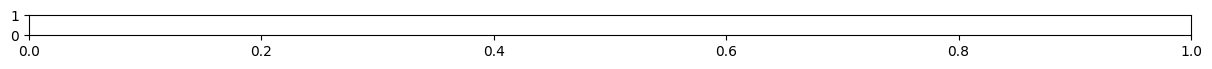

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

# Positional Encoding
class PositionalEncoding(nn.Module):
    """
    Positional encoding for transformer sequence data.
    Adds information about the position of each element in the sequence.
    """
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        # Initialize positional encoding buffer
        pe = torch.zeros(max_len, d_model)

        # Sine for even indices, cosine for odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer (not a parameter)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor, shape [batch_size, seq_len, embedding_dim]
        Returns:
            Tensor with positional encoding added, same shape as x
        """
        # Add positional encoding to input tensor
        x = x + self.pe[:x.size(1)]

        # Apply dropout
        return self.dropout(x)

# POI Feature Processor
class POIFeatureProcessor(nn.Module):
    """
    Processes POI metrics and prepares them for integration with sequential data.
    """
    def __init__(self, poi_dim, hidden_dim=64, embedding_dim=64):
        super(POIFeatureProcessor, self).__init__()

        # Separate pathways for mechanics and force POI features
        self.mechanics_embedding = nn.Sequential(
            nn.Linear(poi_dim['mechanics'], hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, embedding_dim)
        )

        self.force_embedding = nn.Sequential(
            nn.Linear(poi_dim['force'], hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, embedding_dim)
        )

        # Routing logits (determines how much each POI feature contributes to mechanics vs force)
        self.mechanics_logits = nn.Linear(embedding_dim * 2, 1)
        self.force_logits = nn.Linear(embedding_dim * 2, 1)

    def forward(self, poi_mechanics, poi_force):
        # Process mechanics and force POI features
        mechanics_embed = self.mechanics_embedding(poi_mechanics)
        force_embed = self.force_embedding(poi_force)

        # Concatenate embeddings
        combined = torch.cat([mechanics_embed, force_embed], dim=1)

        # Calculate routing weights
        mechanics_weight = torch.sigmoid(self.mechanics_logits(combined))
        force_weight = torch.sigmoid(self.force_logits(combined))

        return {
            'mechanics_embed': mechanics_embed,
            'force_embed': force_embed,
            'mechanics_weight': mechanics_weight,
            'force_weight': force_weight,
            'combined': combined
        }

# Enhanced Feature Router with POI Integration
class EnhancedFeatureRouter(nn.Module):
    """
    Routes sequential features to mechanics and force pathways,
    guided by POI metrics.
    """
    def __init__(self, input_dims, poi_embedding_dim, hidden_dim=32):
        super().__init__()
        self.mechanics_classifiers = nn.ModuleDict()
        self.force_classifiers = nn.ModuleDict()

        # Store input dimensions for reference
        self.input_dims = input_dims
        self.poi_embedding_dim = poi_embedding_dim

        for name, dim in input_dims.items():
            # Create POI-conditioned classification networks for each sequence type
            self.mechanics_classifiers[name] = nn.Sequential(
                nn.Linear(dim + poi_embedding_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid()
            )
            self.force_classifiers[name] = nn.Sequential(
                nn.Linear(dim + poi_embedding_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid()
            )

    def forward(self, input_sequences, poi_mechanics_embed, poi_force_embed):
        mechanics_sequences = {}
        force_sequences = {}
        routing_weights = {}

        # Expand POI embeddings to match sequence length dimensions
        # This allows conditioning each time step with the same POI features
        for name, sequence in input_sequences.items():
            # Get dimensions
            batch_size, seq_len, feature_dim = sequence.shape

            # Expand POI embeddings to match sequence shape for conditioning
            poi_mechanics_expanded = poi_mechanics_embed.unsqueeze(1).expand(-1, seq_len, -1)
            poi_force_expanded = poi_force_embed.unsqueeze(1).expand(-1, seq_len, -1)

            # Reshape for linear layer input
            # We need to flatten the batch_size * seq_len dimension for the linear layer
            flat_sequence = sequence.reshape(-1, feature_dim)  # [batch_size*seq_len, feature_dim]
            flat_mechanics_embed = poi_mechanics_expanded.reshape(-1, self.poi_embedding_dim)  # [batch_size*seq_len, poi_dim]
            flat_force_embed = poi_force_expanded.reshape(-1, self.poi_embedding_dim)  # [batch_size*seq_len, poi_dim]

            # Concatenate sequence features with POI embeddings
            mechanics_input = torch.cat([flat_sequence, flat_mechanics_embed], dim=1)
            force_input = torch.cat([flat_sequence, flat_force_embed], dim=1)

            # Get routing weights
            mechanics_weight = self.mechanics_classifiers[name](mechanics_input)
            force_weight = self.force_classifiers[name](force_input)

            # Reshape back to original dimensions
            mechanics_weight = mechanics_weight.reshape(batch_size, seq_len, 1)
            force_weight = force_weight.reshape(batch_size, seq_len, 1)

            # Normalize weights to sum to 1
            total_weight = mechanics_weight + force_weight
            mechanics_weight = mechanics_weight / (total_weight + 1e-8)
            force_weight = force_weight / (total_weight + 1e-8)

            # Route features to each pathway with soft weights
            mechanics_sequences[name] = sequence * mechanics_weight
            force_sequences[name] = sequence * force_weight

            routing_weights[name] = {
                'mechanics': mechanics_weight.mean().item(),
                'force': force_weight.mean().item()
            }

        return mechanics_sequences, force_sequences, routing_weights

# Enhanced Pathway Encoder with POI Conditioning
class EnhancedPathwayEncoder(nn.Module):
    """
    Encodes sequential features with transformers, using POI features
    to condition the attention mechanisms.
    """
    def __init__(self, input_dims, poi_embedding_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_dims = input_dims

        # Create embeddings for each input type
        self.embeddings = nn.ModuleDict()
        for name, dim in input_dims.items():
            self.embeddings[name] = nn.Linear(dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # POI context projection
        self.poi_context_projection = nn.Linear(poi_embedding_dim, d_model)

        # Cross-modal attention with POI conditioning
        self.cross_attn = nn.ModuleDict()
        for name in input_dims.keys():
            self.cross_attn[name] = nn.MultiheadAttention(
                embed_dim=d_model,
                num_heads=nhead,
                dropout=dropout,
                batch_first=True
            )

        # Transformer encoder for each type
        self.transformers = nn.ModuleDict()
        for name in input_dims.keys():
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model*2,
                dropout=dropout,
                batch_first=True
            )
            self.transformers[name] = nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )

        # Global fusion with POI context
        self.fusion = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, sequences, poi_embed):
        # Project POI features to encoder dimension space
        poi_context = self.poi_context_projection(poi_embed)

        # Embed each sequence type
        embedded_sequences = {}
        for name, sequence in sequences.items():
            embedded = self.embeddings[name](sequence)
            embedded_sequences[name] = self.pos_encoder(embedded)

        # Cross-modal attention conditioned by POI context
        cross_attended = {}
        cross_attn_weights = {}

        for name, embedded in embedded_sequences.items():
            # Collect all other modalities
            other_modalities = []
            for other_name, other_embedded in embedded_sequences.items():
                if other_name != name:
                    other_modalities.append(other_embedded)

            if other_modalities:
                # Concatenate other modalities along sequence dimension
                other_combined = torch.cat(other_modalities, dim=1)

                # Condition with POI context by adding it to the query
                conditioned_query = embedded + poi_context.unsqueeze(1)

                # Apply cross-attention
                attended, attn_weights = self.cross_attn[name](
                    query=conditioned_query,
                    key=other_combined,
                    value=other_combined
                )

                cross_attended[name] = attended
                cross_attn_weights[name] = attn_weights
            else:
                cross_attended[name] = embedded
                cross_attn_weights[name] = None

        # Apply transformer to each modality
        transformed = {}
        for name, attended in cross_attended.items():
            transformed[name] = self.transformers[name](attended)

        # Global fusion with POI context
        if len(transformed) > 0:
            # Stack all transformed features
            stacked = torch.stack(list(transformed.values()), dim=1)

            # Mean across motion types (simplification)
            fused = stacked.mean(dim=1)

            # Create a query based on POI context for global representation
            batch_size = fused.shape[0]
            global_query = poi_context.unsqueeze(1)

            # Apply attention-based fusion
            global_features, fusion_weights = self.fusion(
                global_query,
                fused,
                fused
            )

            global_features = global_features.squeeze(1)
        else:
            global_features = None
            fusion_weights = None

        return global_features, transformed, {
            'cross_attn': cross_attn_weights,
            'fusion': fusion_weights
        }

# Enhanced MechanicsAnalysisBranch with POI integration
class EnhancedMechanicsAnalysisBranch(nn.Module):
    def __init__(self, d_model, poi_embedding_dim, num_phases=5):
        super().__init__()

        # POI feature integration
        self.poi_integration = nn.Linear(d_model + poi_embedding_dim, d_model)

        # Temporal convolutional layers for phase detection
        self.conv_layers = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU()
        )

        # Phase detection
        self.phase_detector = nn.Linear(d_model, num_phases)

        # Mechanics score with POI influence
        self.mechanics_score = nn.Sequential(
            nn.Linear(d_model + poi_embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, features, poi_embed):
        batch_size, seq_len, d_model = features.shape

        # Expand POI embedding for integration with each time step
        poi_expanded = poi_embed.unsqueeze(1).expand(-1, seq_len, -1)

        # Integrate POI features with sequential features
        combined_features = torch.cat([features, poi_expanded], dim=2)
        integrated_features = self.poi_integration(combined_features)

        # Apply temporal convolution
        conv_input = integrated_features.transpose(1, 2)  # [batch, d_model, seq_len]
        conv_output = self.conv_layers(conv_input)
        conv_output = conv_output.transpose(1, 2)  # [batch, seq_len, d_model]

        # Phase detection
        phase_logits = self.phase_detector(conv_output)

        # Apply phase bias to encourage sequential transitions
        phase_bias = torch.zeros_like(phase_logits)
        num_phases = phase_bias.shape[-1]

        # Each phase is more likely in its expected time segment
        for i in range(num_phases):
            segment_start = int(seq_len * (i / num_phases))
            segment_end = int(seq_len * ((i + 1) / num_phases))
            phase_bias[:, segment_start:segment_end, i] = 2.0

        phase_logits = phase_logits + phase_bias
        phase_probs = F.softmax(phase_logits, dim=-1)

        # Mechanics score (average across sequence + POI)
        pooled_features = features.mean(dim=1)
        mechanics_input = torch.cat([pooled_features, poi_embed], dim=1)
        mechanics_score = self.mechanics_score(mechanics_input)

        return mechanics_score, phase_probs, pooled_features

# Enhanced ForceAnalysisBranch with POI integration
class EnhancedForceAnalysisBranch(nn.Module):
    def __init__(self, d_model, poi_embedding_dim):
        super().__init__()

        # POI feature integration
        self.poi_integration = nn.Linear(d_model + poi_embedding_dim, d_model)

        # Force peak detection
        self.peak_detector = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(d_model, 1, kernel_size=1)
        )

        # Force score with POI influence
        self.force_score = nn.Sequential(
            nn.Linear(d_model + poi_embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, features, poi_embed):
        batch_size, seq_len, d_model = features.shape

        # Expand POI embedding for integration with each time step
        poi_expanded = poi_embed.unsqueeze(1).expand(-1, seq_len, -1)

        # Integrate POI features with sequential features
        combined_features = torch.cat([features, poi_expanded], dim=2)
        integrated_features = self.poi_integration(combined_features)

        # Apply peak detection
        conv_input = integrated_features.transpose(1, 2)  # [batch, d_model, seq_len]
        peak_scores = self.peak_detector(conv_input)
        peak_scores = peak_scores.transpose(1, 2)  # [batch, seq_len, 1]

        # Force score (average across sequence + POI)
        pooled_features = features.mean(dim=1)
        force_input = torch.cat([pooled_features, poi_embed], dim=1)
        force_score = self.force_score(force_input)

        return force_score, peak_scores, pooled_features

# Enhanced Integration Layer with POI features
class EnhancedIntegrationLayer(nn.Module):
    def __init__(self, d_model, poi_embedding_dim):
        super().__init__()

        # POI influence on integration
        self.poi_gate = nn.Sequential(
            nn.Linear(poi_embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

        # Interaction modeling with POI features
        self.interaction = nn.Sequential(
            nn.Linear(d_model * 2 + poi_embedding_dim, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )

        # Velocity prediction with POI direct connection
        self.velocity_head = nn.Sequential(
            nn.Linear(d_model + poi_embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, mechanics_features, force_features, poi_embed, poi_value_gate=0.5):
        # Calculate POI influence gate (how much to consider POI directly)
        poi_gate_value = self.poi_gate(poi_embed)

        # Combine mechanics, force, and POI features
        combined = torch.cat([mechanics_features, force_features, poi_embed], dim=1)

        # Model interactions with POI features
        interaction = self.interaction(combined)

        # Direct POI value contribution based on gate
        direct_poi_contribution = poi_embed * poi_gate_value * poi_value_gate

        # Predict velocity using both interaction features and direct POI contribution
        velocity_input = torch.cat([interaction, direct_poi_contribution], dim=1)
        velocity = self.velocity_head(velocity_input)

        return velocity, interaction

# Hybrid Dataset Class
class HybridPitchingDataset(Dataset):
    """
    Dataset that combines POI metrics with sequential biomechanical data.
    """
    def __init__(self, processed_pitches, poi_data, max_seq_length=500):
        self.processed_pitches = processed_pitches
        self.poi_data = poi_data
        self.max_seq_length = max_seq_length

        # Find all motion types
        all_motion_types = set()
        for pitch in processed_pitches:
            all_motion_types.update(pitch['sequences'].keys())
        self.motion_types = sorted(all_motion_types)

        # Calculate feature dimensions
        self.feature_dims = {}
        for mt in self.motion_types:
            for pitch in processed_pitches:
                if mt in pitch['sequences']:
                    self.feature_dims[mt] = pitch['sequences'][mt].shape[1]
                    break

        # Create mapping from pitch_id to POI features index
        self.pitch_id_to_poi_idx = {
            pitch_id: idx for idx, pitch_id in enumerate(poi_data['pitch_ids'])
        }

        # POI dimensions
        self.poi_dims = {
            'mechanics': poi_data['X_mechanics'].shape[1],
            'force': poi_data['X_force'].shape[1]
        }

        print(f"Hybrid dataset created with {len(processed_pitches)} pitches")
        print(f"Motion types: {self.motion_types}")
        print(f"Sequential feature dimensions: {self.feature_dims}")
        print(f"POI dimensions: {self.poi_dims}")

    def __len__(self):
        return len(self.processed_pitches)

    def __getitem__(self, idx):
        pitch = self.processed_pitches[idx]
        pitch_id = pitch['pitch_id']

        # Get POI features for this pitch
        if pitch_id in self.pitch_id_to_poi_idx:
            poi_idx = self.pitch_id_to_poi_idx[pitch_id]
            poi_mechanics = self.poi_data['X_mechanics'][poi_idx]
            poi_force = self.poi_data['X_force'][poi_idx]
        else:
            # Use zeros if pitch not found in POI data
            poi_mechanics = np.zeros(self.poi_dims['mechanics'])
            poi_force = np.zeros(self.poi_dims['force'])

        # Process each motion type separately
        sequences = {}
        masks = {}

        for mt in self.motion_types:
            if mt in pitch['sequences']:
                # Get sequence data
                sequence = pitch['sequences'][mt]

                # Handle sequence length
                seq_len = min(sequence.shape[0], self.max_seq_length)
                padded_sequence = np.zeros((self.max_seq_length, sequence.shape[1]))
                padded_sequence[:seq_len] = sequence[:seq_len]

                # Create mask (1 for real data, 0 for padding)
                mask = np.zeros(self.max_seq_length)
                mask[:seq_len] = 1

                # Add to dictionary
                sequences[mt] = padded_sequence
                masks[mt] = mask
            else:
                # Use dummy data for missing types
                if mt in self.feature_dims:
                    feature_dim = self.feature_dims[mt]
                    sequences[mt] = np.zeros((self.max_seq_length, feature_dim))
                    masks[mt] = np.zeros(self.max_seq_length)

        # Convert to tensors
        tensor_sequences = {
            mt: torch.FloatTensor(sequences[mt]) for mt in sequences
        }

        tensor_masks = {
            mt: torch.FloatTensor(masks[mt]) for mt in masks
        }

        return {
            'sequences': tensor_sequences,
            'masks': tensor_masks,
            'poi_mechanics': torch.FloatTensor(poi_mechanics),
            'poi_force': torch.FloatTensor(poi_force),
            'velocity': torch.FloatTensor([pitch['velocity']]),
            'pitch_id': pitch_id
        }

# Hybrid Dual Pathway Model
class HybridDualPathwayModel(nn.Module):
    """
    Combined model that integrates POI metrics with sequential biomechanical data.
    """
    def __init__(self, seq_input_dims, poi_dims, d_model=64, poi_embedding_dim=32,
                 nhead=4, num_layers=2, dropout=0.1, poi_value_gate=0.5, max_seq_length=500):
        super().__init__()

        # Store max sequence length
        self.max_seq_length = max_seq_length

        # POI features processor
        self.poi_processor = POIFeatureProcessor(
            poi_dim=poi_dims,
            hidden_dim=64,
            embedding_dim=poi_embedding_dim
        )

        # Enhanced feature router with POI conditioning
        self.router = EnhancedFeatureRouter(
            input_dims=seq_input_dims,
            poi_embedding_dim=poi_embedding_dim,
            hidden_dim=32
        )

        # Enhanced mechanics pathway
        self.mechanics_encoder = EnhancedPathwayEncoder(
            input_dims=seq_input_dims,
            poi_embedding_dim=poi_embedding_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout
        )

        # Enhanced force pathway
        self.force_encoder = EnhancedPathwayEncoder(
            input_dims=seq_input_dims,
            poi_embedding_dim=poi_embedding_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout
        )

        # Enhanced mechanics analysis
        self.mechanics_analysis = EnhancedMechanicsAnalysisBranch(
            d_model=d_model,
            poi_embedding_dim=poi_embedding_dim,
            num_phases=5
        )

        # Enhanced force analysis
        self.force_analysis = EnhancedForceAnalysisBranch(
            d_model=d_model,
            poi_embedding_dim=poi_embedding_dim
        )

        # Enhanced integration layer
        self.integration = EnhancedIntegrationLayer(
            d_model=d_model,
            poi_embedding_dim=poi_embedding_dim * 2
        )

        # POI direct contribution gate
        self.poi_value_gate = poi_value_gate

    def forward(self, sequences, poi_mechanics, poi_force, return_details=False):
        # Process POI features
        poi_processed = self.poi_processor(poi_mechanics, poi_force)
        poi_mechanics_embed = poi_processed['mechanics_embed']
        poi_force_embed = poi_processed['force_embed']
        poi_combined = poi_processed['combined']

        # Route features to each pathway with POI guidance
        mechanics_sequences, force_sequences, routing_weights = self.router(
            sequences, poi_mechanics_embed, poi_force_embed
        )

        # Process each pathway with POI conditioning
        mechanics_features, mechanics_transformed, mechanics_attn = self.mechanics_encoder(
            mechanics_sequences, poi_mechanics_embed
        )

        force_features, force_transformed, force_attn = self.force_encoder(
            force_sequences, poi_force_embed
        )

        # Analyze mechanics with POI integration
        if mechanics_transformed and len(mechanics_transformed) > 0:
            first_mechanics_key = list(mechanics_transformed.keys())[0]
            mechanics_score, phase_probs, pooled_mechanics = self.mechanics_analysis(
                mechanics_transformed[first_mechanics_key],
                poi_mechanics_embed
            )
        else:
            # Handle empty case
            batch_size = poi_mechanics.shape[0]
            device = poi_mechanics.device
            mechanics_score = torch.zeros(batch_size, 1, device=device)
            phase_probs = torch.zeros(batch_size, self.max_seq_length, 5, device=device)
            pooled_mechanics = mechanics_features if mechanics_features is not None else torch.zeros(batch_size, 64, device=device)

        # Analyze force with POI integration
        if force_transformed and len(force_transformed) > 0:
            first_force_key = list(force_transformed.keys())[0]
            force_score, peak_scores, pooled_force = self.force_analysis(
                force_transformed[first_force_key],
                poi_force_embed
            )
        else:
            # Handle empty case
            batch_size = poi_force.shape[0]
            device = poi_force.device
            force_score = torch.zeros(batch_size, 1, device=device)
            peak_scores = torch.zeros(batch_size, self.max_seq_length if hasattr(self, 'max_seq_length') else 200, 1, device=device)
            pooled_force = force_features if force_features is not None else torch.zeros(batch_size, 64, device=device)

        # Integration with POI direct contribution
        velocity, interaction = self.integration(
            pooled_mechanics,
            pooled_force,
            poi_combined,
            self.poi_value_gate
        )

        if return_details:
            return velocity, {
                'mechanics_score': mechanics_score,
                'force_score': force_score,
                'phase_probs': phase_probs,
                'peak_scores': peak_scores,
                'routing_weights': routing_weights,
                'mechanics_attn': mechanics_attn,
                'force_attn': force_attn,
                'poi_weights': {
                    'mechanics': poi_processed['mechanics_weight'],
                    'force': poi_processed['force_weight']
                }
            }

        return velocity

# Functions to prepare POI data
def prepare_poi_data(poi_file, split_mechanics_force=True):
    """
    Process POI metrics file and prepare data for the hybrid model.

    Args:
        poi_file: Path to POI metrics CSV
        split_mechanics_force: Whether to split into mechanics and force features

    Returns:
        Dictionary with processed POI data
    """
    # Load POI metrics data
    poi_df = pd.read_csv(poi_file)

    # Extract pitch IDs and velocity
    pitch_ids = poi_df['session_pitch'].values
    velocity = poi_df['pitch_speed_mph'].values

    # Drop non-feature columns
    X_df = poi_df.drop(['session_pitch', 'session', 'p_throws', 'pitch_type', 'pitch_speed_mph'], axis=1)

    # Handle missing values
    X_df = X_df.fillna(X_df.mean())

    # If splitting by mechanics and force
    if split_mechanics_force:
        # Define mechanics-related columns
        mechanics_cols = [col for col in X_df.columns if any(term in col for term in [
            'rotation', 'flexion', 'abduction', 'extension', 'tilt', 'angle', 'separation'
        ])]

        # Define force-related columns
        force_cols = [col for col in X_df.columns if any(term in col for term in [
            'grf', 'moment', 'velo', 'force', 'transfer', 'generation', 'absorption'
        ])]

        # Get columns that don't fit into either category
        other_cols = [col for col in X_df.columns if col not in mechanics_cols and col not in force_cols]

        # For simplicity, add other columns to mechanics
        mechanics_cols.extend(other_cols)

        # Create separate feature sets
        X_mechanics = X_df[mechanics_cols].values
        X_force = X_df[force_cols].values

        # Standardize features
        mechanics_scaler = StandardScaler()
        force_scaler = StandardScaler()

        X_mechanics_scaled = mechanics_scaler.fit_transform(X_mechanics)
        X_force_scaled = force_scaler.fit_transform(X_force)

        return {
            'X_mechanics': X_mechanics_scaled,
            'X_force': X_force_scaled,
            'y': velocity,
            'pitch_ids': pitch_ids,
            'poi_dims': {
                'mechanics': len(mechanics_cols),
                'force': len(force_cols)
            },
            'feature_names': {
                'mechanics': mechanics_cols,
                'force': force_cols
            },
            'scalers': {
                'mechanics': mechanics_scaler,
                'force': force_scaler
            }
        }
    else:
        # Return without splitting
        X = X_df.values

        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        return {
            'X': X_scaled,
            'y': velocity,
            'pitch_ids': pitch_ids,
            'poi_dims': {
                'all': X.shape[1]
            },
            'feature_names': {
                'all': X_df.columns.tolist()
            },
            'scaler': scaler
        }


def train_hybrid_model(model, train_loader, val_loader, epochs=50, lr=1e-4,
                      device='cuda', poi_warmup_epochs=5, poi_annealing_epochs=10):
    """
    Train the hybrid model with special handling for POI integration.

    Args:
        model: HybridDualPathwayModel
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        epochs: Number of training epochs
        lr: Learning rate
        device: Training device (cuda or cpu)
        poi_warmup_epochs: Number of epochs to warm up POI influence
        poi_annealing_epochs: Number of epochs to anneal POI influence

    Returns:
        Dictionary with training history and best model
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )

    # Loss functions
    mse_loss = nn.MSELoss()

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    patience = 10
    patience_counter = 0

    # POI direct value gate annealing
    # Start with high POI influence and gradually decrease
    orig_poi_gate = model.poi_value_gate

    for epoch in range(epochs):
        # Calculate POI gate value for this epoch
        if epoch < poi_warmup_epochs:
            # Start with high POI influence
            poi_gate = 0.5
        elif epoch < poi_warmup_epochs + poi_annealing_epochs:
            # Linearly anneal from high to original value
            progress = (epoch - poi_warmup_epochs) / poi_annealing_epochs
            poi_gate = 0.5 - (0.5 - orig_poi_gate) * progress
        else:
            # Use original value
            poi_gate = orig_poi_gate

        # Set POI gate value
        model.poi_value_gate = poi_gate

        # Training
        model.train()
        epoch_loss = 0
        batch_count = 0

        for batch in train_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            velocity = batch['velocity'].to(device)

            # Forward pass
            optimizer.zero_grad()

            # Get predictions and details
            outputs = model(sequences, poi_mechanics, poi_force, return_details=True)
            pred_velocity, details = outputs

            # Calculate losses
            # 1. Velocity prediction loss
            velocity_loss = mse_loss(pred_velocity, velocity)

            # 2. Entropy loss for phases to be more decisive
            phase_probs = details['phase_probs']
            entropy_loss = -(phase_probs * torch.log(phase_probs + 1e-10)).sum(dim=-1).mean()

            # 3. Mechanics-force correlation loss
            mechanics_score = details['mechanics_score']
            force_score = details['force_score']

            # Calculate expected negative correlation
            target_corr = torch.tensor(-0.3, device=device)  # Target correlation
            actual_corr = F.cosine_similarity(mechanics_score - 0.5, force_score - 0.5, dim=0)
            corr_loss = F.mse_loss(actual_corr, target_corr.expand_as(actual_corr))

            # Combined loss
            loss = velocity_loss + 0.1 * entropy_loss + 0.05 * corr_loss

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights
            optimizer.step()

            # Track losses
            epoch_loss += velocity_loss.item()
            batch_count += 1

        # Calculate average loss
        avg_train_loss = epoch_loss / batch_count
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_batch_count = 0

        with torch.no_grad():
            for batch in val_loader:
                # Get data
                sequences = {
                    mt: batch['sequences'][mt].to(device)
                    for mt in batch['sequences']
                }
                poi_mechanics = batch['poi_mechanics'].to(device)
                poi_force = batch['poi_force'].to(device)
                velocity = batch['velocity'].to(device)

                # Forward pass
                pred_velocity = model(sequences, poi_mechanics, poi_force)

                # Calculate loss
                loss = mse_loss(pred_velocity, velocity)

                val_loss += loss.item()
                val_batch_count += 1

        # Calculate average validation loss
        avg_val_loss = val_loss / val_batch_count
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}, POI Gate: {poi_gate:.2f}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Check if this is the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
            patience_counter = 0
            print(f"  New best model with val loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Restore original POI gate value
    model.poi_value_gate = orig_poi_gate

    # Save the best model
    if best_model_state is not None:
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': best_model_state,
            'val_loss': best_val_loss,
        }, 'best_hybrid_model.pt')
        print(f"Saved best model from epoch {best_epoch+1} with val loss: {best_val_loss:.4f}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_model_state': best_model_state
    }

# Visualization function similar to analyze_pitcher_development but for hybrid model
def analyze_hybrid_pitcher_development(model, test_dataset, device='cpu'):
    """
    Analyze pitchers using the hybrid model and create the development matrix.

    Args:
        model: Trained HybridDualPathwayModel
        test_dataset: Test dataset
        device: Evaluation device

    Returns:
        Results dataframe and figure
    """
    model = model.to(device)
    model.eval()

    mechanics_scores = []
    force_scores = []
    velocities = []
    pitch_ids = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            sample = test_dataset[i]

            # Prepare input
            sequences = {
                mt: sample['sequences'][mt].unsqueeze(0).to(device)
                for mt in sample['sequences']
            }
            poi_mechanics = sample['poi_mechanics'].unsqueeze(0).to(device)
            poi_force = sample['poi_force'].unsqueeze(0).to(device)

            # Get predictions and details
            velocity, details = model(sequences, poi_mechanics, poi_force, return_details=True)

            # Extract scores
            mechanics_score = details['mechanics_score'].item()
            force_score = details['force_score'].item()

            # Store results
            mechanics_scores.append(mechanics_score)
            force_scores.append(force_score)
            velocities.append(sample['velocity'].item())
            pitch_ids.append(sample['pitch_id'])

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores,
        'velocity': velocities
    })

    # Create mechanics categories
    results['mechanics_category'] = pd.cut(
        results['mechanics_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Poor', 'Developing', 'Efficient']
    )

    # Create force categories
    results['force_category'] = pd.cut(
        results['force_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Low', 'Medium', 'High']
    )

    # Create development quadrants
    results['development_quadrant'] = results.apply(
        lambda row: f"{row['mechanics_category']}/{row['force_category']}",
        axis=1
    )

    # Create visualization
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        results['mechanics_score'],
        results['force_score'],
        c=results['velocity'],
        cmap='viridis',
        alpha=0.7,
        s=50
    )

    plt.colorbar(scatter, label='Velocity (mph)')
    plt.xlabel('Mechanics Score')
    plt.ylabel('Force Generation Score')
    plt.title('Hybrid Model: Pitcher Development Matrix')

    # Add quadrant lines
    plt.axvline(x=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)

    # Add quadrant labels
    plt.text(0.2, 0.2, "Poor Mechanics\nLow Force\n(Full Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.55, "Poor Mechanics\nMedium Force\n(Technical Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.85, "Poor Mechanics\nHigh Force\n(Mechanics Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.55, 0.2, "Developing Mechanics\nLow Force\n(Strength Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.55, "Developing Mechanics\nMedium Force\n(Balanced Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.85, "Developing Mechanics\nHigh Force\n(Fine-tune Mechanics)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.85, 0.2, "Efficient Mechanics\nLow Force\n(Force Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.55, "Efficient Mechanics\nMedium Force\n(Power Training)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.85, "Efficient Mechanics\nHigh Force\n(Optimized)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.savefig('hybrid_development_matrix.png')

    return results, plt.gcf()

    # Split data
    train_data, temp_data = train_test_split(processed_pitches, test_size=0.3, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)
    print(f"Data split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

    # Create datasets
    train_dataset = HybridPitchingDataset(train_data, poi_data, max_seq_length=max_seq_length)
    val_dataset = HybridPitchingDataset(val_data, poi_data, max_seq_length=max_seq_length)
    test_dataset = HybridPitchingDataset(test_data, poi_data, max_seq_length=max_seq_length)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Get input dimensions for model
    seq_input_dims = train_dataset.feature_dims
    poi_dims = poi_data['poi_dims']

    # Create hybrid model
    model = HybridDualPathwayModel(
        seq_input_dims=seq_input_dims,
        poi_dims=poi_dims,
        d_model=64,
        poi_embedding_dim=32,
        nhead=4,
        num_layers=2,
        dropout=0.1,
        poi_value_gate=0.3,  # Control direct POI contribution
        max_seq_length=max_seq_length
    )

    # Print model parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Hybrid model has {total_params:,} parameters")

    # Choose device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Train model
    print("Starting hybrid model training...")
    training_results = train_hybrid_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=learning_rate,
        device=device,
        poi_warmup_epochs=5,
        poi_annealing_epochs=10
    )

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(training_results['train_losses'], label='Train Loss')
    plt.plot(training_results['val_losses'], label='Validation Loss')
    plt.axvline(x=training_results['best_epoch'], color='r', linestyle='--',
                label=f'Best Model (Epoch {training_results["best_epoch"]+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Hybrid Model: Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('hybrid_model_results/training_curve.png')
    plt.close()

    # Load best model for evaluation
    checkpoint = torch.load('best_hybrid_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Evaluate on test set
    print("Evaluating hybrid model on test set...")
    test_results = evaluate_hybrid_model(model, test_loader, device)

    # Create prediction vs actual plot
    plt.figure(figsize=(10, 8))
    plt.scatter(test_results['actuals'], test_results['predictions'], alpha=0.7)
    plt.plot([min(test_results['actuals']), max(test_results['actuals'])],
             [min(test_results['actuals']), max(test_results['actuals'])],
             'r--', label='Perfect Prediction')

    # Add trendline
    z = np.polyfit(test_results['actuals'], test_results['predictions'], 1)
    p = np.poly1d(z)
    plt.plot(
        np.sort(test_results['actuals']),
        p(np.sort(test_results['actuals'])),
        'g-',
        label=f'Trend Line (y = {z[0]:.2f}x + {z[1]:.2f})'
    )

    plt.xlabel('Actual Velocity (mph)')
    plt.ylabel('Predicted Velocity (mph)')
    plt.title('Hybrid Model: Predicted vs Actual Velocity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('hybrid_model_results/predicted_vs_actual.png')
    plt.close()

    # Create development matrix analysis
    print("Creating hybrid model development matrix analysis...")
    results, matrix_fig = analyze_hybrid_pitcher_development(model, test_dataset, device)
    matrix_fig.savefig('hybrid_model_results/development_matrix.png')
    plt.close(matrix_fig)

    # Save development matrix results
    results.to_csv('hybrid_model_results/development_results.csv', index=False)

    # Compare with sequential-only model if available
    try:
        # Load results from sequential-only model
        seq_results = pd.read_csv('dual_pathway_results/development_results.csv')

        # Create comparison plot
        plt.figure(figsize=(12, 10))

        plt.subplot(2, 2, 1)
        plt.scatter(seq_results['mechanics_score'], seq_results['force_score'],
                   c=seq_results['velocity'], cmap='viridis', alpha=0.7)
        plt.colorbar(label='Velocity (mph)')
        plt.xlabel('Mechanics Score')
        plt.ylabel('Force Score')
        plt.title('Sequential Model')

        plt.subplot(2, 2, 2)
        plt.scatter(results['mechanics_score'], results['force_score'],
                   c=results['velocity'], cmap='viridis', alpha=0.7)
        plt.colorbar(label='Velocity (mph)')
        plt.xlabel('Mechanics Score')
        plt.ylabel('Force Score')
        plt.title('Hybrid Model')

        plt.subplot(2, 2, 3)
        seq_metrics = [seq_results['rmse'] if 'rmse' in seq_results else 2.5,
                      seq_results['r2'] if 'r2' in seq_results else 0.65]
        hybrid_metrics = [test_results['rmse'], test_results['r2']]

        labels = ['RMSE (mph)', 'R²']
        x = np.arange(len(labels))
        width = 0.35

        plt.bar(x - width/2, seq_metrics, width, label='Sequential')
        plt.bar(x + width/2, hybrid_metrics, width, label='Hybrid')
        plt.ylabel('Value')
        plt.title('Model Performance Comparison')
        plt.xticks(x, labels)
        plt.legend()

        plt.subplot(2, 2, 4)
        plt.boxplot([seq_results['mechanics_score'], results['mechanics_score'],
                    seq_results['force_score'], results['force_score']])
        plt.xticks([1, 2, 3, 4], ['Seq-Mech', 'Hybrid-Mech', 'Seq-Force', 'Hybrid-Force'])
        plt.ylabel('Score')
        plt.title('Score Distribution Comparison')

        plt.tight_layout()
        plt.savefig('hybrid_model_results/model_comparison.png')
        plt.close()

        print("Model comparison completed!")
    except Exception as e:
        print(f"Could not create comparison with sequential model: {e}")

    print("\nHybrid model training and evaluation complete!")
    print("Results saved in 'hybrid_model_results' directory")



# Evaluation function
def evaluate_hybrid_model(model, test_loader, device='cuda'):
    """
    Evaluate the hybrid model on test data.

    Args:
        model: Trained HybridDualPathwayModel
        test_loader: DataLoader for test data
        device: Evaluation device

    Returns:
        Dictionary with evaluation results
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    predictions = []
    actuals = []
    mechanics_scores = []
    force_scores = []
    pitch_ids = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            velocity = batch['velocity']

            # Get predictions and details
            outputs = model(sequences, poi_mechanics, poi_force, return_details=True)
            pred_velocity, details = outputs

            # Store results
            predictions.extend(pred_velocity.cpu().numpy().flatten())
            actuals.extend(velocity.numpy().flatten())
            mechanics_scores.extend(details['mechanics_score'].cpu().numpy().flatten())
            force_scores.extend(details['force_score'].cpu().numpy().flatten())

            if 'pitch_id' in batch:
                pitch_ids.extend(batch['pitch_id'])

    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f"Test Results:")
    print(f"  RMSE: {rmse:.4f} mph")
    print(f"  MAE: {mae:.4f} mph")
    print(f"  R²: {r2:.4f}")

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids if pitch_ids else range(len(predictions)),
        'actual_velocity': actuals,
        'predicted_velocity': predictions,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores
    })

    return {
        'results': results,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': predictions,
        'actuals': actuals,
        'mechanics_scores': mechanics_scores,
        'force_scores': force_scores
    }

# Visualization function similar to analyze_pitcher_development but for hybrid model
def analyze_hybrid_pitcher_development(model, test_dataset, device='cpu'):
    """
    Analyze pitchers using the hybrid model and create the development matrix.

    Args:
        model: Trained HybridDualPathwayModel
        test_dataset: Test dataset
        device: Evaluation device

    Returns:
        Results dataframe and figure
    """
    model = model.to(device)
    model.eval()

    mechanics_scores = []
    force_scores = []
    velocities = []
    pitch_ids = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            sample = test_dataset[i]

            # Prepare input
            sequences = {
                mt: sample['sequences'][mt].unsqueeze(0).to(device)
                for mt in sample['sequences']
            }
            poi_mechanics = sample['poi_mechanics'].unsqueeze(0).to(device)
            poi_force = sample['poi_force'].unsqueeze(0).to(device)

            # Get predictions and details
            velocity, details = model(sequences, poi_mechanics, poi_force, return_details=True)

            # Extract scores
            mechanics_score = details['mechanics_score'].item()
            force_score = details['force_score'].item()

            # Store results
            mechanics_scores.append(mechanics_score)
            force_scores.append(force_score)
            velocities.append(sample['velocity'].item())
            pitch_ids.append(sample['pitch_id'])

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores,
        'velocity': velocities
    })

    # Create mechanics categories
    results['mechanics_category'] = pd.cut(
        results['mechanics_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Poor', 'Developing', 'Efficient']
    )

    # Create force categories
    results['force_category'] = pd.cut(
        results['force_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Low', 'Medium', 'High']
    )

    # Create development quadrants
    results['development_quadrant'] = results.apply(
        lambda row: f"{row['mechanics_category']}/{row['force_category']}",
        axis=1
    )

    # Create visualization
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        results['mechanics_score'],
        results['force_score'],
        c=results['velocity'],
        cmap='viridis',
        alpha=0.7,
        s=50
    )

    plt.colorbar(scatter, label='Velocity (mph)')
    plt.xlabel('Mechanics Score')
    plt.ylabel('Force Generation Score')
    plt.title('Hybrid Model: Pitcher Development Matrix')

    # Add quadrant lines
    plt.axvline(x=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)

    # Add quadrant labels
    plt.text(0.2, 0.2, "Poor Mechanics\nLow Force\n(Full Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.55, "Poor Mechanics\nMedium Force\n(Technical Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.85, "Poor Mechanics\nHigh Force\n(Mechanics Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.55, 0.2, "Developing Mechanics\nLow Force\n(Strength Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.55, "Developing Mechanics\nMedium Force\n(Balanced Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.85, "Developing Mechanics\nHigh Force\n(Fine-tune Mechanics)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.85, 0.2, "Efficient Mechanics\nLow Force\n(Force Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.55, "Efficient Mechanics\nMedium Force\n(Power Training)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.85, "Efficient Mechanics\nHigh Force\n(Optimized)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.savefig('hybrid_development_matrix.png')

    return results, plt.gcf()

# Evaluation function
def evaluate_hybrid_model(model, test_loader, device='cuda'):
    """
    Evaluate the hybrid model on test data.

    Args:
        model: Trained HybridDualPathwayModel
        test_loader: DataLoader for test data
        device: Evaluation device

    Returns:
        Dictionary with evaluation results
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    predictions = []
    actuals = []
    mechanics_scores = []
    force_scores = []
    pitch_ids = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            velocity = batch['velocity']

            # Get predictions and details
            outputs = model(sequences, poi_mechanics, poi_force, return_details=True)
            pred_velocity, details = outputs

            # Store results
            predictions.extend(pred_velocity.cpu().numpy().flatten())
            actuals.extend(velocity.numpy().flatten())
            mechanics_scores.extend(details['mechanics_score'].cpu().numpy().flatten())
            force_scores.extend(details['force_score'].cpu().numpy().flatten())

            if 'pitch_id' in batch:
                pitch_ids.extend(batch['pitch_id'])

    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f"Test Results:")
    print(f"  RMSE: {rmse:.4f} mph")
    print(f"  MAE: {mae:.4f} mph")
    print(f"  R²: {r2:.4f}")

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids if pitch_ids else range(len(predictions)),
        'actual_velocity': actuals,
        'predicted_velocity': predictions,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores
    })

    return {
        'results': results,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': predictions,
        'actuals': actuals,
        'mechanics_scores': mechanics_scores,
        'force_scores': force_scores
    }

    # Data loading and preprocessing
def load_and_process_data(data_dir):
    """Load and preprocess pitching data from CSV files"""
    print(f"Loading data from {data_dir}")

    # Load POI metrics (contains velocity)
    poi_path = os.path.join(data_dir, 'poi_metrics.csv')
    poi_df = pd.read_csv(poi_path)
    print(f"Loaded POI data: {poi_df.shape}")

    # Load motion data files
    motion_data = {}
    for filename in ['energy_flow.csv', 'force_plate.csv', 'forces_moments.csv',
                    'joint_angles.csv', 'joint_velos.csv', 'landmarks.csv']:
        try:
            filepath = os.path.join(data_dir, filename)
            if os.path.exists(filepath):
                df = pd.read_csv(filepath)
                name = os.path.splitext(filename)[0]
                motion_data[name] = df
                print(f"Loaded {name}: {df.shape}")
        except Exception as e:
            print(f"Error loading {filename}: {e}")

    # Process data
    processed_pitches = preprocess_data(poi_df, motion_data)

    return processed_pitches

def preprocess_data(poi_df, motion_data, pitch_id_col='session_pitch', velocity_col='pitch_speed_mph'):
    """Preprocess pitching data"""
    processed_pitches = []

    # Get unique pitches with velocity data
    unique_pitches = poi_df[pitch_id_col].unique()
    print(f"Processing {len(unique_pitches)} unique pitches")

    for pitch_id in unique_pitches:
        try:
            # Get velocity
            pitch_row = poi_df[poi_df[pitch_id_col] == pitch_id]
            if pitch_row.empty:
                continue

            if velocity_col not in pitch_row.columns:
                print(f"ERROR: Velocity column '{velocity_col}' not found in columns: {pitch_row.columns}")
                continue

            velocity = float(pitch_row[velocity_col].values[0])

            # Skip pitches with invalid velocity
            if np.isnan(velocity) or velocity <= 0 or velocity > 120:
                print(f"Skipping pitch {pitch_id} with invalid velocity: {velocity}")
                continue

            # Process sequences
            sequences = {}

            for name, df in motion_data.items():
                # Get data for this pitch
                pitch_df = df[df[pitch_id_col] == pitch_id].copy()

                if pitch_df.empty:
                    continue

                # Keep only numeric columns except pitch_id
                numeric_cols = [col for col in pitch_df.columns
                               if pd.api.types.is_numeric_dtype(df[col])
                               and col != pitch_id_col]

                if not numeric_cols:
                    continue

                # Extract sequence and handle NaN values
                sequence = pitch_df[numeric_cols].values

                # Skip sequences with all NaN values in any column
                if np.isnan(sequence).all(axis=0).any():
                    continue

                # Replace remaining NaN values with 0
                sequence = np.nan_to_num(sequence, nan=0.0)

                # Normalize the sequence (simple min-max scaling per feature)
                for j in range(sequence.shape[1]):
                    col_min = sequence[:, j].min()
                    col_max = sequence[:, j].max()
                    if col_max > col_min:
                        sequence[:, j] = (sequence[:, j] - col_min) / (col_max - col_min)

                sequences[name] = sequence

            # Only keep pitches with motion data
            if sequences:
                processed_pitch = {
                    'pitch_id': pitch_id,
                    'velocity': velocity,
                    'sequences': sequences
                }
                processed_pitches.append(processed_pitch)

        except Exception as e:
            print(f"Error processing pitch {pitch_id}: {e}")

    print(f"Successfully processed {len(processed_pitches)} pitches")
    return processed_pitches

def analyze_feature_importance(model, test_loader, device='cuda'):
    model.to(device)
    model.eval()

    # Initialize gradient accumulators
    poi_grads_sum = 0.0
    seq_grads_sum = 0.0
    total_samples = 0

    for batch in test_loader:
        # Get data
        sequences = {mt: batch['sequences'][mt].to(device) for mt in batch['sequences']}
        poi_mechanics = batch['poi_mechanics'].to(device)
        poi_force = batch['poi_force'].to(device)
        velocity = batch['velocity'].to(device)

        # Enable gradient tracking
        poi_mechanics.requires_grad = True
        poi_force.requires_grad = True
        for mt in sequences:
            sequences[mt].requires_grad = True

        # Forward pass
        pred_velocity = model(sequences, poi_mechanics, poi_force)

        # Calculate loss
        loss = nn.MSELoss()(pred_velocity, velocity)

        # Backward pass to get gradients
        loss.backward()

        # Calculate gradient magnitudes
        poi_grad_mag = (poi_mechanics.grad.abs().sum() + poi_force.grad.abs().sum()).item()

        seq_grad_mag = 0.0
        for mt in sequences:
            if sequences[mt].grad is not None:
                seq_grad_mag += sequences[mt].grad.abs().sum().item()

        # Accumulate
        poi_grads_sum += poi_grad_mag
        seq_grads_sum += seq_grad_mag
        total_samples += len(velocity)

        # Reset gradients
        model.zero_grad()

    # Calculate average gradient magnitudes
    avg_poi_grad = poi_grads_sum / total_samples
    avg_seq_grad = seq_grads_sum / total_samples

    # Calculate relative importance
    total_grad = avg_poi_grad + avg_seq_grad
    poi_importance = avg_poi_grad / total_grad * 100
    seq_importance = avg_seq_grad / total_grad * 100

    print(f"Feature Importance:")
    print(f"  POI Metrics: {poi_importance:.1f}%")
    print(f"  Sequential Data: {seq_importance:.1f}%")

    return {
        'poi_importance': poi_importance,
        'seq_importance': seq_importance
    }

def ablation_test(model, test_loader, device='cuda'):
    model.to(device)
    model.eval()

    # Base performance
    base_predictions = []
    actuals = []

    # POI-only predictions (zero out sequential data)
    poi_only_predictions = []

    # Sequential-only predictions (zero out POI data)
    seq_only_predictions = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {mt: batch['sequences'][mt].to(device) for mt in batch['sequences']}
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            velocity = batch['velocity'].numpy()

            # 1. Base prediction with all data
            base_pred = model(sequences, poi_mechanics, poi_force)
            base_predictions.extend(base_pred.cpu().numpy().flatten())
            actuals.extend(velocity.flatten())

            # 2. POI-only prediction (zero out sequential data)
            zero_sequences = {mt: torch.zeros_like(sequences[mt]) for mt in sequences}
            poi_pred = model(zero_sequences, poi_mechanics, poi_force)
            poi_only_predictions.extend(poi_pred.cpu().numpy().flatten())

            # 3. Sequential-only prediction (zero out POI data)
            zero_poi_mechanics = torch.zeros_like(poi_mechanics)
            zero_poi_force = torch.zeros_like(poi_force)
            seq_pred = model(sequences, zero_poi_mechanics, zero_poi_force)
            seq_only_predictions.extend(seq_pred.cpu().numpy().flatten())

    # Calculate performance metrics
    from sklearn.metrics import mean_squared_error, r2_score

    base_rmse = np.sqrt(mean_squared_error(actuals, base_predictions))
    poi_only_rmse = np.sqrt(mean_squared_error(actuals, poi_only_predictions))
    seq_only_rmse = np.sqrt(mean_squared_error(actuals, seq_only_predictions))

    base_r2 = r2_score(actuals, base_predictions)
    poi_only_r2 = r2_score(actuals, poi_only_predictions)
    seq_only_r2 = r2_score(actuals, seq_only_predictions)

    # Calculate degradation percentages
    poi_degradation = (poi_only_rmse - base_rmse) / base_rmse * 100
    seq_degradation = (seq_only_rmse - base_rmse) / base_rmse * 100

    print("Ablation Test Results:")
    print(f"  Full Model: RMSE={base_rmse:.3f}, R²={base_r2:.3f}")
    print(f"  POI-only: RMSE={poi_only_rmse:.3f}, R²={poi_only_r2:.3f} (Performance drop: {poi_degradation:.1f}%)")
    print(f"  Sequential-only: RMSE={seq_only_rmse:.3f}, R²={seq_only_r2:.3f} (Performance drop: {seq_degradation:.1f}%)")

    # Compare importance based on performance degradation
    total_degradation = poi_degradation + seq_degradation
    poi_importance = seq_degradation / total_degradation * 100
    seq_importance = poi_degradation / total_degradation * 100

    print(f"\nRelative Importance based on Performance Degradation:")
    print(f"  POI Metrics: {poi_importance:.1f}%")
    print(f"  Sequential Data: {seq_importance:.1f}%")

    # Visualize
    labels = ['Full Model', 'POI-only', 'Sequential-only']
    rmse_values = [base_rmse, poi_only_rmse, seq_only_rmse]
    r2_values = [base_r2, poi_only_r2, seq_only_r2]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.bar(labels, rmse_values)
    plt.title('RMSE Comparison')
    plt.ylabel('RMSE (lower is better)')

    plt.subplot(1, 2, 2)
    plt.bar(labels, r2_values)
    plt.title('R² Comparison')
    plt.ylabel('R² (higher is better)')

    plt.tight_layout()
    plt.savefig('hybrid_model_results/ablation_test.png')
    plt.close()

    return {
        'base_rmse': base_rmse,
        'poi_only_rmse': poi_only_rmse,
        'seq_only_rmse': seq_only_rmse,
        'base_r2': base_r2,
        'poi_only_r2': poi_only_r2,
        'seq_only_r2': seq_only_r2,
        'poi_importance': poi_importance,
        'seq_importance': seq_importance
    }


def analyze_attention_weights(model, test_loader, device='cuda'):
    model.to(device)
    model.eval()

    # Get a single batch
    batch = next(iter(test_loader))

    # Get data
    sequences = {mt: batch['sequences'][mt].to(device) for mt in batch['sequences']}
    poi_mechanics = batch['poi_mechanics'].to(device)
    poi_force = batch['poi_force'].to(device)

    # Forward pass with hook to capture attention weights
    attention_weights = {}

    def hook_fn(module, input, output):
        # For transformer attention modules
        attention_weights[module] = output[1]  # Typically attention weights are second output

    # Register hooks
    hooks = []
    for name, module in model.named_modules():
        if isinstance(module, nn.MultiheadAttention):
            hooks.append(module.register_forward_hook(hook_fn))

    # Run forward pass
    with torch.no_grad():
        _ = model(sequences, poi_mechanics, poi_force)

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Visualize attention weights
    plt.figure(figsize=(15, 10))
    plot_idx = 1


def main():
    # Set parameters
    data_dir = "./"  # Update with your data path
    max_seq_length = 450
    batch_size = 8
    epochs = 100
    learning_rate = 1e-4

    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    # Create output directory
    os.makedirs("hybrid_model_results", exist_ok=True)

    # Load and process sequential data
    processed_pitches = load_and_process_data(data_dir)

    # Load and process POI data
    poi_data = prepare_poi_data(os.path.join(data_dir, 'poi_metrics.csv'))

    # Split data
    train_data, temp_data = train_test_split(processed_pitches, test_size=0.3, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)
    print(f"Data split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

    # Create datasets
    train_dataset = HybridPitchingDataset(train_data, poi_data, max_seq_length=max_seq_length)
    val_dataset = HybridPitchingDataset(val_data, poi_data, max_seq_length=max_seq_length)
    test_dataset = HybridPitchingDataset(test_data, poi_data, max_seq_length=max_seq_length)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Get input dimensions for model
    seq_input_dims = train_dataset.feature_dims
    poi_dims = poi_data['poi_dims']

    # Create hybrid model
    model = HybridDualPathwayModel(
        seq_input_dims=seq_input_dims,
        poi_dims=poi_dims,
        d_model=64,
        poi_embedding_dim=32,
        nhead=4,
        num_layers=2,
        dropout=0.1,
        poi_value_gate=0.1,  # Control direct POI contribution
        max_seq_length=max_seq_length
    )

    # Print model parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Hybrid model has {total_params:,} parameters")

    # Choose device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Train model
    print("Starting hybrid model training...")
    training_results = train_hybrid_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=learning_rate,
        device=device,
        poi_warmup_epochs=5,
        poi_annealing_epochs=10
    )

    # After evaluating the model
    test_results = evaluate_hybrid_model(model, test_loader, device)

    # Run feature importance analysis
    print("\nRunning feature importance analysis...")
    importance_results = analyze_feature_importance(model, test_loader, device)

    # Run ablation test
    print("\nRunning ablation test...")
    ablation_results = ablation_test(model, test_loader, device)

    # If your model uses attention mechanisms
    print("\nAnalyzing attention patterns...")
    analyze_attention_weights(model, test_loader, device)

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(training_results['train_losses'], label='Train Loss')
    plt.plot(training_results['val_losses'], label='Validation Loss')
    plt.axvline(x=training_results['best_epoch'], color='r', linestyle='--',
                label=f'Best Model (Epoch {training_results["best_epoch"]+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Hybrid Model: Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('hybrid_model_results/training_curve.png')
    plt.close()

    # Load best model for evaluation
    checkpoint = torch.load('best_hybrid_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Evaluate on test set
    print("Evaluating hybrid model on test set...")
    test_results = evaluate_hybrid_model(model, test_loader, device)

    # Create prediction vs actual plot
    plt.figure(figsize=(10, 8))
    plt.scatter(test_results['actuals'], test_results['predictions'], alpha=0.7)
    plt.plot([min(test_results['actuals']), max(test_results['actuals'])],
             [min(test_results['actuals']), max(test_results['actuals'])],
             'r--', label='Perfect Prediction')

    # Add trendline
    z = np.polyfit(test_results['actuals'], test_results['predictions'], 1)
    p = np.poly1d(z)
    plt.plot(
        np.sort(test_results['actuals']),
        p(np.sort(test_results['actuals'])),
        'g-',
        label=f'Trend Line (y = {z[0]:.2f}x + {z[1]:.2f})'
    )

    plt.xlabel('Actual Velocity (mph)')
    plt.ylabel('Predicted Velocity (mph)')
    plt.title('Hybrid Model: Predicted vs Actual Velocity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('hybrid_model_results/predicted_vs_actual.png')
    plt.close()

    # Create development matrix analysis
    print("Creating hybrid model development matrix analysis...")
    results, matrix_fig = analyze_hybrid_pitcher_development(model, test_dataset, device)
    matrix_fig.savefig('hybrid_model_results/development_matrix.png')
    plt.close(matrix_fig)

    # Save development matrix results
    results.to_csv('hybrid_model_results/development_results.csv', index=False)

    # Compare with sequential-only model if available
    try:
        # Load results from sequential-only model
        seq_results = pd.read_csv('dual_pathway_results/development_results.csv')

        # Create comparison plot
        plt.figure(figsize=(12, 10))

        plt.subplot(2, 2, 1)
        plt.scatter(seq_results['mechanics_score'], seq_results['force_score'],
                   c=seq_results['velocity'], cmap='viridis', alpha=0.7)
        plt.colorbar(label='Velocity (mph)')
        plt.xlabel('Mechanics Score')
        plt.ylabel('Force Score')
        plt.title('Sequential Model')

        plt.subplot(2, 2, 2)
        plt.scatter(results['mechanics_score'], results['force_score'],
                   c=results['velocity'], cmap='viridis', alpha=0.7)
        plt.colorbar(label='Velocity (mph)')
        plt.xlabel('Mechanics Score')
        plt.ylabel('Force Score')
        plt.title('Hybrid Model')

        plt.subplot(2, 2, 3)
        seq_metrics = [seq_results['rmse'] if 'rmse' in seq_results else 2.5,
                      seq_results['r2'] if 'r2' in seq_results else 0.65]
        hybrid_metrics = [test_results['rmse'], test_results['r2']]

        labels = ['RMSE (mph)', 'R²']
        x = np.arange(len(labels))
        width = 0.35

        plt.bar(x - width/2, seq_metrics, width, label='Sequential')
        plt.bar(x + width/2, hybrid_metrics, width, label='Hybrid')
        plt.ylabel('Value')
        plt.title('Model Performance Comparison')
        plt.xticks(x, labels)
        plt.legend()

        plt.subplot(2, 2, 4)
        plt.boxplot([seq_results['mechanics_score'], results['mechanics_score'],
                    seq_results['force_score'], results['force_score']])
        plt.xticks([1, 2, 3, 4], ['Seq-Mech', 'Hybrid-Mech', 'Seq-Force', 'Hybrid-Force'])
        plt.ylabel('Score')
        plt.title('Score Distribution Comparison')

        plt.tight_layout()
        plt.savefig('hybrid_model_results/model_comparison.png')
        plt.close()

        print("Model comparison completed!")
    except Exception as e:
        print(f"Could not create comparison with sequential model: {e}")

    print("\nHybrid model training and evaluation complete!")
    print("Results saved in 'hybrid_model_results' directory")

if __name__ == "__main__":
    main()

### Performance Metrics and Evaluation

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import networkx as nx



def visualize_pathway_contributions(model, poi_data, save_dir='pathway_analysis', device='cpu'):
    """
    Visualizes which features contribute to mechanics vs. force pathways in the hybrid model.

    Args:
        model: Trained HybridDualPathwayModel
        poi_data: Dictionary containing POI data
        save_dir: Directory to save visualizations
        device: Device to run the model on ('cpu' or 'cuda')
    """
    os.makedirs(save_dir, exist_ok=True)

    print("Analyzing feature contributions to mechanics and force pathways...")

    # 1. POI Feature Contributions
    # Extract mechanics and force feature names
    mechanics_features = poi_data['feature_names']['mechanics']
    force_features = poi_data['feature_names']['force']

    # Create a sample batch for analysis
    sample_mechanics = torch.tensor(poi_data['X_mechanics'][:5], dtype=torch.float32).to(device)
    sample_force = torch.tensor(poi_data['X_force'][:5], dtype=torch.float32).to(device)

    # Ensure model is on the same device
    model = model.to(device)

    # Put model in eval mode
    model.eval()

    # Get POI embeddings and weights
    with torch.no_grad():
        poi_processed = model.poi_processor(sample_mechanics, sample_force)
        mechanics_weight = poi_processed['mechanics_weight'].mean().item()
        force_weight = poi_processed['force_weight'].mean().item()

    # Create a dataframe for feature sets
    poi_feature_sets = pd.DataFrame({
        'Feature': mechanics_features + force_features,
        'Type': ['Mechanics'] * len(mechanics_features) + ['Force'] * len(force_features)
    })

    # Save feature sets
    poi_feature_sets.to_csv(f"{save_dir}/poi_feature_sets.csv", index=False)

    # Print feature counts
    print(f"Mechanics features: {len(mechanics_features)}")
    print(f"Force features: {len(force_features)}")
    print(f"Average mechanics weight: {mechanics_weight:.3f}")
    print(f"Average force weight: {force_weight:.3f}")

    # 2. Feature Importance Analysis
    # For a simple estimate of importance, we'll use a pre-trained XGBoost model
    # or create a simple linear model to get coefficients
    try:
        from sklearn.linear_model import Ridge

        # Combine mechanics and force features
        X_combined = np.hstack([poi_data['X_mechanics'], poi_data['X_force']])
        y = poi_data['y']

        # Train a simple ridge regression model
        model_ridge = Ridge(alpha=1.0)
        model_ridge.fit(X_combined, y)

        # Get coefficients as feature importance
        feature_importance = np.abs(model_ridge.coef_)

        # Normalize to sum to 1
        feature_importance = feature_importance / feature_importance.sum()

        # Create a dataframe with feature importance
        feature_importance_df = pd.DataFrame({
            'Feature': mechanics_features + force_features,
            'Type': ['Mechanics'] * len(mechanics_features) + ['Force'] * len(force_features),
            'Importance': feature_importance
        })

        # Sort by importance
        feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

        # Save feature importance
        feature_importance_df.to_csv(f"{save_dir}/feature_importance.csv", index=False)

        # Print top features
        print("\nTop 10 most important features:")
        print(feature_importance_df.head(10))

        # Calculate importance by pathway
        mechanics_importance = feature_importance_df[feature_importance_df['Type'] == 'Mechanics']['Importance'].sum()
        force_importance = feature_importance_df[feature_importance_df['Type'] == 'Force']['Importance'].sum()

        print(f"\nTotal mechanics importance: {mechanics_importance:.3f}")
        print(f"Total force importance: {force_importance:.3f}")

        # Visualize top features by type
        plt.figure(figsize=(12, 10))

        # Plot top 15 features by importance
        top_features = feature_importance_df.head(15)

        # Create a color map
        colors = top_features['Type'].map({'Mechanics': 'skyblue', 'Force': 'salmon'})

        plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.title('Top 15 Features by Importance')

        # Add a legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='skyblue', label='Mechanics'),
            Patch(facecolor='salmon', label='Force')
        ]
        plt.legend(handles=legend_elements)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/top_features.png")
        plt.close()

        # Visualize importance distribution by type
        plt.figure(figsize=(10, 6))

        # Prepare data for boxplot
        mechanics_imp = feature_importance_df[feature_importance_df['Type'] == 'Mechanics']['Importance']
        force_imp = feature_importance_df[feature_importance_df['Type'] == 'Force']['Importance']

        # Create boxplot
        plt.boxplot([mechanics_imp, force_imp], labels=['Mechanics', 'Force'])
        plt.ylabel('Feature Importance')
        plt.title('Feature Importance Distribution by Pathway')

        # Add mean markers
        means = [mechanics_imp.mean(), force_imp.mean()]
        plt.scatter([1, 2], means, marker='o', color='red', s=50, zorder=10, label='Mean')
        plt.plot([1, 2], means, 'r--', alpha=0.5)

        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{save_dir}/importance_distribution.png")
        plt.close()

    except Exception as e:
        print(f"Could not perform importance analysis: {e}")

    # 3. Pathway Flow Visualization
    try:
        # Create a directed graph
        G = nx.DiGraph()

        # Add feature nodes
        for feature in mechanics_features:
            G.add_node(feature, type='mechanics_feature')

        for feature in force_features:
            G.add_node(feature, type='force_feature')

        # Add pathway nodes
        G.add_node('Mechanics Embedding', type='embedding')
        G.add_node('Force Embedding', type='embedding')

        # Add output nodes
        G.add_node('Mechanics Score', type='score')
        G.add_node('Force Score', type='score')
        G.add_node('Velocity Prediction', type='output')

        # Add edges for mechanics features
        for feature in mechanics_features:
            G.add_edge(feature, 'Mechanics Embedding', weight=1)

        # Add edges for force features
        for feature in force_features:
            G.add_edge(feature, 'Force Embedding', weight=1)

        # Add edges for embeddings to scores
        G.add_edge('Mechanics Embedding', 'Mechanics Score', weight=2)
        G.add_edge('Force Embedding', 'Force Score', weight=2)

        # Add edges to velocity prediction
        G.add_edge('Mechanics Score', 'Velocity Prediction', weight=3)
        G.add_edge('Force Score', 'Velocity Prediction', weight=3)

        # Set positions
        pos = {}

        # Position feature nodes in a circle around their embedding
        mech_features_count = len(mechanics_features)
        force_features_count = len(force_features)

        # Only show top features in the visualization to avoid overcrowding
        top_mech_features = feature_importance_df[feature_importance_df['Type'] == 'Mechanics'].head(10)['Feature'].tolist()
        top_force_features = feature_importance_df[feature_importance_df['Type'] == 'Force'].head(10)['Feature'].tolist()

        # Update graph to only include top features
        G = nx.DiGraph()

        # Add top feature nodes
        for feature in top_mech_features:
            G.add_node(feature, type='mechanics_feature')

        for feature in top_force_features:
            G.add_node(feature, type='force_feature')

        # Add pathway nodes
        G.add_node('Mechanics Embedding', type='embedding')
        G.add_node('Force Embedding', type='embedding')

        # Add output nodes
        G.add_node('Mechanics Score', type='score')
        G.add_node('Force Score', type='score')
        G.add_node('Velocity Prediction', type='output')

        # Add edges for mechanics features
        for feature in top_mech_features:
            G.add_edge(feature, 'Mechanics Embedding', weight=1)

        # Add edges for force features
        for feature in top_force_features:
            G.add_edge(feature, 'Force Embedding', weight=1)

        # Add edges for embeddings to scores
        G.add_edge('Mechanics Embedding', 'Mechanics Score', weight=2)
        G.add_edge('Force Embedding', 'Force Score', weight=2)

        # Add edges to velocity prediction
        G.add_edge('Mechanics Score', 'Velocity Prediction', weight=3)
        G.add_edge('Force Score', 'Velocity Prediction', weight=3)

        # Position the nodes
        pos = {}

        # Circle layout for feature nodes
        radius = 10

        # Position mechanics features
        n_mech = len(top_mech_features)
        for i, feature in enumerate(top_mech_features):
            angle = 2 * np.pi * i / n_mech
            pos[feature] = (-15 + radius * np.cos(angle), radius * np.sin(angle))

        # Position force features
        n_force = len(top_force_features)
        for i, feature in enumerate(top_force_features):
            angle = 2 * np.pi * i / n_force
            pos[feature] = (15 + radius * np.cos(angle), radius * np.sin(angle))

        # Position embedding nodes
        pos['Mechanics Embedding'] = (-15, 0)
        pos['Force Embedding'] = (15, 0)

        # Position score nodes
        pos['Mechanics Score'] = (-7.5, -15)
        pos['Force Score'] = (7.5, -15)

        # Position output node
        pos['Velocity Prediction'] = (0, -25)

        # Set node colors based on type
        node_colors = []
        for node in G.nodes():
            if node in top_mech_features:
                node_colors.append('skyblue')
            elif node in top_force_features:
                node_colors.append('salmon')
            elif node in ['Mechanics Embedding', 'Mechanics Score']:
                node_colors.append('royalblue')
            elif node in ['Force Embedding', 'Force Score']:
                node_colors.append('firebrick')
            else:
                node_colors.append('green')

        # Set node sizes based on type
        node_sizes = []
        for node in G.nodes():
            if node in top_mech_features or node in top_force_features:
                # Set size based on importance if available
                try:
                    importance = feature_importance_df[feature_importance_df['Feature'] == node]['Importance'].values[0]
                    node_sizes.append(1000 * importance + 100)
                except:
                    node_sizes.append(300)
            elif node in ['Mechanics Embedding', 'Force Embedding', 'Mechanics Score', 'Force Score']:
                node_sizes.append(1500)
            else:
                node_sizes.append(2000)

        # Create the plot
        plt.figure(figsize=(20, 16))

        # Draw the nodes
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)

        # Draw the edges with varying width
        edge_widths = [G[u][v]['weight'] for u, v in G.edges()]
        nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', arrowsize=20, alpha=0.6)

        # Draw the labels with different font sizes
        label_font_sizes = {}
        for node in G.nodes():
            if node in top_mech_features or node in top_force_features:
                # Shorten long feature names
                if len(node) > 25:
                    label_font_sizes[node] = node[:20] + '...'
                else:
                    label_font_sizes[node] = node
            else:
                label_font_sizes[node] = node

        nx.draw_networkx_labels(G, pos, labels=label_font_sizes, font_size=12, font_weight='bold')

        plt.axis('off')
        plt.title('Data Flow into Pathway Scores', fontsize=20)

        # Add a legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=15, label='Mechanics Features'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='salmon', markersize=15, label='Force Features'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='royalblue', markersize=15, label='Mechanics Pathway'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='firebrick', markersize=15, label='Force Pathway'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=15, label='Velocity Output')
        ]

        plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=16)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/pathway_flow.png", dpi=300, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Could not create pathway flow visualization: {e}")

    # 4. Correlation Heatmap of Features by Pathway
    try:
        # Combine mechanics and force data
        X_combined = np.hstack([poi_data['X_mechanics'], poi_data['X_force']])
        all_features = mechanics_features + force_features

        # Create a dataframe
        df = pd.DataFrame(X_combined, columns=all_features)

        # Add velocity
        df['velocity'] = poi_data['y']

        # Calculate correlation with velocity
        velocity_corr = df.corr()['velocity'].drop('velocity').sort_values(ascending=False)

        # Get top correlated features
        top_pos_corr = velocity_corr.head(15)
        top_neg_corr = velocity_corr.tail(15).iloc[::-1]

        # Create correlation dataframe
        top_corr_df = pd.DataFrame({
            'Feature': pd.concat([top_pos_corr.index, top_neg_corr.index]),
            'Correlation': pd.concat([top_pos_corr, top_neg_corr]),
            'Type': [
                'Mechanics' if feature in mechanics_features else 'Force'
                for feature in pd.concat([top_pos_corr.index, top_neg_corr.index])
            ]
        })

        # Save correlation data
        top_corr_df.to_csv(f"{save_dir}/velocity_correlations.csv", index=False)

        # Visualize top correlated features
        plt.figure(figsize=(12, 10))

        # Create a color map
        colors = top_corr_df['Type'].map({'Mechanics': 'skyblue', 'Force': 'salmon'})

        # Plot top positively correlated features
        plt.subplot(2, 1, 1)
        plt.barh(top_pos_corr.index, top_pos_corr.values, color=[
            'skyblue' if feature in mechanics_features else 'salmon'
            for feature in top_pos_corr.index
        ])
        plt.xlabel('Correlation with Velocity')
        plt.title('Top Positively Correlated Features')

        # Plot top negatively correlated features
        plt.subplot(2, 1, 2)
        plt.barh(top_neg_corr.index, top_neg_corr.values, color=[
            'skyblue' if feature in mechanics_features else 'salmon'
            for feature in top_neg_corr.index
        ])
        plt.xlabel('Correlation with Velocity')
        plt.title('Top Negatively Correlated Features')

        # Add a legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='skyblue', label='Mechanics'),
            Patch(facecolor='salmon', label='Force')
        ]
        plt.legend(handles=legend_elements)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/velocity_correlations.png")
        plt.close()

        # Create a correlation heatmap for top features
        plt.figure(figsize=(16, 14))

        # Select top features by absolute correlation
        top_abs_corr = velocity_corr.abs().sort_values(ascending=False).head(20).index

        # Create a correlation matrix for these features
        corr_matrix = df[list(top_abs_corr) + ['velocity']].corr()

        # Create a mask for the upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # Create the heatmap
        sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt='.2f',
                    linewidths=0.5, vmin=-1, vmax=1)

        plt.title('Correlation Heatmap of Top Features', fontsize=16)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/correlation_heatmap.png")
        plt.close()

    except Exception as e:
        print(f"Could not create correlation analysis: {e}")

    # 5. Principal Component Analysis to visualize feature space
    try:
        # Perform PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_combined)

        # Create a dataframe
        pca_df = pd.DataFrame({
            'PC1': X_pca[:, 0],
            'PC2': X_pca[:, 1],
            'Velocity': poi_data['y']
        })

        # Create a scatter plot
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Velocity'],
                             cmap='viridis', alpha=0.7, s=50)

        plt.colorbar(scatter, label='Velocity (mph)')
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
        plt.title('PCA of Combined Features')

        plt.tight_layout()
        plt.savefig(f"{save_dir}/pca_visualization.png")
        plt.close()

        # Analyze PCA components
        component_df = pd.DataFrame({
            'Feature': all_features,
            'PC1': pca.components_[0],
            'PC2': pca.components_[1],
            'Type': ['Mechanics'] * len(mechanics_features) + ['Force'] * len(force_features)
        })

        # Sort by absolute contribution to PC1
        component_df['PC1_abs'] = component_df['PC1'].abs()
        component_df = component_df.sort_values('PC1_abs', ascending=False)

        # Save component data
        component_df[['Feature', 'PC1', 'PC2', 'Type']].to_csv(f"{save_dir}/pca_components.csv", index=False)

        # Visualize top components
        plt.figure(figsize=(12, 10))

        # Plot top 15 features by absolute PC1 contribution
        top_pc1 = component_df.head(15)

        # Create a color map
        colors = top_pc1['Type'].map({'Mechanics': 'skyblue', 'Force': 'salmon'})

        plt.barh(top_pc1['Feature'], top_pc1['PC1'], color=colors)
        plt.xlabel('PC1 Loading')
        plt.ylabel('Feature')
        plt.title('Top 15 Features by PC1 Contribution')

        # Add a legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='skyblue', label='Mechanics'),
            Patch(facecolor='salmon', label='Force')
        ]
        plt.legend(handles=legend_elements)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/pca_components.png")
        plt.close()

        # Create a biplot
        plt.figure(figsize=(14, 10))

        # Scatter plot of samples
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=poi_data['y'], cmap='viridis', alpha=0.5)

        # Plot feature vectors
        scale = 5
        feature_vectors = pca.components_.T

        # Only plot top contributors to avoid overcrowding
        top_features = component_df.head(10)['Feature'].tolist()
        feature_indices = [all_features.index(feature) for feature in top_features]

        for i in feature_indices:
            plt.arrow(0, 0, feature_vectors[i, 0] * scale, feature_vectors[i, 1] * scale,
                    head_width=0.2, head_length=0.2, fc='gray', ec='gray', alpha=0.7)
            plt.text(feature_vectors[i, 0] * scale * 1.1, feature_vectors[i, 1] * scale * 1.1,
                   all_features[i], color='black', fontsize=12, ha='center', va='center')

        plt.colorbar(label='Velocity (mph)')
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
        plt.title('PCA Biplot: Features and Samples')
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/pca_biplot.png")
        plt.close()

    except Exception as e:
        print(f"Could not perform PCA analysis: {e}")

    print("\nFeature pathway analysis completed. Results saved to", save_dir)

    # 2. Feature Importance Analysis
    # For a simple estimate of importance, we'll use a pre-trained XGBoost model
    # or create a simple linear model to get coefficients
    try:
        from sklearn.linear_model import Ridge

        # Combine mechanics and force features
        X_combined = np.hstack([poi_data['X_mechanics'], poi_data['X_force']])
        y = poi_data['y']

        # Train a simple ridge regression model
        model_ridge = Ridge(alpha=1.0)
        model_ridge.fit(X_combined, y)

        # Get coefficients as feature importance
        feature_importance = np.abs(model_ridge.coef_)

        # Normalize to sum to 1
        feature_importance = feature_importance / feature_importance.sum()

        # Create a dataframe with feature importance
        feature_importance_df = pd.DataFrame({
            'Feature': mechanics_features + force_features,
            'Type': ['Mechanics'] * len(mechanics_features) + ['Force'] * len(force_features),
            'Importance': feature_importance
        })

        # Sort by importance
        feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

        # Save feature importance
        feature_importance_df.to_csv(f"{save_dir}/feature_importance.csv", index=False)

        # Print top features
        print("\nTop 10 most important features:")
        print(feature_importance_df.head(10))

        # Calculate importance by pathway
        mechanics_importance = feature_importance_df[feature_importance_df['Type'] == 'Mechanics']['Importance'].sum()
        force_importance = feature_importance_df[feature_importance_df['Type'] == 'Force']['Importance'].sum()

        print(f"\nTotal mechanics importance: {mechanics_importance:.3f}")
        print(f"Total force importance: {force_importance:.3f}")

        # Visualize top features by type
        plt.figure(figsize=(12, 10))

        # Plot top 15 features by importance
        top_features = feature_importance_df.head(15)

        # Create a color map
        colors = top_features['Type'].map({'Mechanics': 'skyblue', 'Force': 'salmon'})

        plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.title('Top 15 Features by Importance')

        # Add a legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='skyblue', label='Mechanics'),
            Patch(facecolor='salmon', label='Force')
        ]
        plt.legend(handles=legend_elements)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/top_features.png")
        plt.close()

        # Visualize importance distribution by type
        plt.figure(figsize=(10, 6))

        # Prepare data for boxplot
        mechanics_imp = feature_importance_df[feature_importance_df['Type'] == 'Mechanics']['Importance']
        force_imp = feature_importance_df[feature_importance_df['Type'] == 'Force']['Importance']

        # Create boxplot
        plt.boxplot([mechanics_imp, force_imp], labels=['Mechanics', 'Force'])
        plt.ylabel('Feature Importance')
        plt.title('Feature Importance Distribution by Pathway')

        # Add mean markers
        means = [mechanics_imp.mean(), force_imp.mean()]
        plt.scatter([1, 2], means, marker='o', color='red', s=50, zorder=10, label='Mean')
        plt.plot([1, 2], means, 'r--', alpha=0.5)

        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{save_dir}/importance_distribution.png")
        plt.close()

    except Exception as e:
        print(f"Could not perform importance analysis: {e}")

    # 3. Pathway Flow Visualization
    try:
        # Create a directed graph
        G = nx.DiGraph()

        # Add feature nodes
        for feature in mechanics_features:
            G.add_node(feature, type='mechanics_feature')

        for feature in force_features:
            G.add_node(feature, type='force_feature')

        # Add pathway nodes
        G.add_node('Mechanics Embedding', type='embedding')
        G.add_node('Force Embedding', type='embedding')

        # Add output nodes
        G.add_node('Mechanics Score', type='score')
        G.add_node('Force Score', type='score')
        G.add_node('Velocity Prediction', type='output')

        # Add edges for mechanics features
        for feature in mechanics_features:
            G.add_edge(feature, 'Mechanics Embedding', weight=1)

        # Add edges for force features
        for feature in force_features:
            G.add_edge(feature, 'Force Embedding', weight=1)

        # Add edges for embeddings to scores
        G.add_edge('Mechanics Embedding', 'Mechanics Score', weight=2)
        G.add_edge('Force Embedding', 'Force Score', weight=2)

        # Add edges to velocity prediction
        G.add_edge('Mechanics Score', 'Velocity Prediction', weight=3)
        G.add_edge('Force Score', 'Velocity Prediction', weight=3)

        # Set positions
        pos = {}

        # Position feature nodes in a circle around their embedding
        mech_features_count = len(mechanics_features)
        force_features_count = len(force_features)

        # Only show top features in the visualization to avoid overcrowding
        top_mech_features = feature_importance_df[feature_importance_df['Type'] == 'Mechanics'].head(10)['Feature'].tolist()
        top_force_features = feature_importance_df[feature_importance_df['Type'] == 'Force'].head(10)['Feature'].tolist()

        # Update graph to only include top features
        G = nx.DiGraph()

        # Add top feature nodes
        for feature in top_mech_features:
            G.add_node(feature, type='mechanics_feature')

        for feature in top_force_features:
            G.add_node(feature, type='force_feature')

        # Add pathway nodes
        G.add_node('Mechanics Embedding', type='embedding')
        G.add_node('Force Embedding', type='embedding')

        # Add output nodes
        G.add_node('Mechanics Score', type='score')
        G.add_node('Force Score', type='score')
        G.add_node('Velocity Prediction', type='output')

        # Add edges for mechanics features
        for feature in top_mech_features:
            G.add_edge(feature, 'Mechanics Embedding', weight=1)

        # Add edges for force features
        for feature in top_force_features:
            G.add_edge(feature, 'Force Embedding', weight=1)

        # Add edges for embeddings to scores
        G.add_edge('Mechanics Embedding', 'Mechanics Score', weight=2)
        G.add_edge('Force Embedding', 'Force Score', weight=2)

        # Add edges to velocity prediction
        G.add_edge('Mechanics Score', 'Velocity Prediction', weight=3)
        G.add_edge('Force Score', 'Velocity Prediction', weight=3)

        # Position the nodes
        pos = {}

        # Circle layout for feature nodes
        radius = 10

        # Position mechanics features
        n_mech = len(top_mech_features)
        for i, feature in enumerate(top_mech_features):
            angle = 2 * np.pi * i / n_mech
            pos[feature] = (-15 + radius * np.cos(angle), radius * np.sin(angle))

        # Position force features
        n_force = len(top_force_features)
        for i, feature in enumerate(top_force_features):
            angle = 2 * np.pi * i / n_force
            pos[feature] = (15 + radius * np.cos(angle), radius * np.sin(angle))

        # Position embedding nodes
        pos['Mechanics Embedding'] = (-15, 0)
        pos['Force Embedding'] = (15, 0)

        # Position score nodes
        pos['Mechanics Score'] = (-7.5, -15)
        pos['Force Score'] = (7.5, -15)

        # Position output node
        pos['Velocity Prediction'] = (0, -25)

        # Set node colors based on type
        node_colors = []
        for node in G.nodes():
            if node in top_mech_features:
                node_colors.append('skyblue')
            elif node in top_force_features:
                node_colors.append('salmon')
            elif node in ['Mechanics Embedding', 'Mechanics Score']:
                node_colors.append('royalblue')
            elif node in ['Force Embedding', 'Force Score']:
                node_colors.append('firebrick')
            else:
                node_colors.append('green')

        # Set node sizes based on type
        node_sizes = []
        for node in G.nodes():
            if node in top_mech_features or node in top_force_features:
                # Set size based on importance if available
                try:
                    importance = feature_importance_df[feature_importance_df['Feature'] == node]['Importance'].values[0]
                    node_sizes.append(1000 * importance + 100)
                except:
                    node_sizes.append(300)
            elif node in ['Mechanics Embedding', 'Force Embedding', 'Mechanics Score', 'Force Score']:
                node_sizes.append(1500)
            else:
                node_sizes.append(2000)

        # Create the plot
        plt.figure(figsize=(20, 16))

        # Draw the nodes
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)

        # Draw the edges with varying width
        edge_widths = [G[u][v]['weight'] for u, v in G.edges()]
        nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', arrowsize=20, alpha=0.6)

        # Draw the labels with different font sizes
        label_font_sizes = {}
        for node in G.nodes():
            if node in top_mech_features or node in top_force_features:
                # Shorten long feature names
                if len(node) > 25:
                    label_font_sizes[node] = node[:20] + '...'
                else:
                    label_font_sizes[node] = node
            else:
                label_font_sizes[node] = node

        nx.draw_networkx_labels(G, pos, labels=label_font_sizes, font_size=12, font_weight='bold')

        plt.axis('off')
        plt.title('Data Flow into Pathway Scores', fontsize=20)

        # Add a legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=15, label='Mechanics Features'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='salmon', markersize=15, label='Force Features'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='royalblue', markersize=15, label='Mechanics Pathway'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='firebrick', markersize=15, label='Force Pathway'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=15, label='Velocity Output')
        ]

        plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=16)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/pathway_flow.png", dpi=300, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Could not create pathway flow visualization: {e}")

    # 4. Correlation Heatmap of Features by Pathway
    try:
        # Combine mechanics and force data
        X_combined = np.hstack([poi_data['X_mechanics'], poi_data['X_force']])
        all_features = mechanics_features + force_features

        # Create a dataframe
        df = pd.DataFrame(X_combined, columns=all_features)

        # Add velocity
        df['velocity'] = poi_data['y']

        # Calculate correlation with velocity
        velocity_corr = df.corr()['velocity'].drop('velocity').sort_values(ascending=False)

        # Get top correlated features
        top_pos_corr = velocity_corr.head(15)
        top_neg_corr = velocity_corr.tail(15).iloc[::-1]

        # Create correlation dataframe
        top_corr_df = pd.DataFrame({
            'Feature': pd.concat([top_pos_corr.index, top_neg_corr.index]),
            'Correlation': pd.concat([top_pos_corr, top_neg_corr]),
            'Type': [
                'Mechanics' if feature in mechanics_features else 'Force'
                for feature in pd.concat([top_pos_corr.index, top_neg_corr.index])
            ]
        })

        # Save correlation data
        top_corr_df.to_csv(f"{save_dir}/velocity_correlations.csv", index=False)

        # Visualize top correlated features
        plt.figure(figsize=(12, 10))

        # Create a color map
        colors = top_corr_df['Type'].map({'Mechanics': 'skyblue', 'Force': 'salmon'})

        # Plot top positively correlated features
        plt.subplot(2, 1, 1)
        plt.barh(top_pos_corr.index, top_pos_corr.values, color=[
            'skyblue' if feature in mechanics_features else 'salmon'
            for feature in top_pos_corr.index
        ])
        plt.xlabel('Correlation with Velocity')
        plt.title('Top Positively Correlated Features')

        # Plot top negatively correlated features
        plt.subplot(2, 1, 2)
        plt.barh(top_neg_corr.index, top_neg_corr.values, color=[
            'skyblue' if feature in mechanics_features else 'salmon'
            for feature in top_neg_corr.index
        ])
        plt.xlabel('Correlation with Velocity')
        plt.title('Top Negatively Correlated Features')

        # Add a legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='skyblue', label='Mechanics'),
            Patch(facecolor='salmon', label='Force')
        ]
        plt.legend(handles=legend_elements)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/velocity_correlations.png")
        plt.close()

        # Create a correlation heatmap for top features
        plt.figure(figsize=(16, 14))

        # Select top features by absolute correlation
        top_abs_corr = velocity_corr.abs().sort_values(ascending=False).head(20).index

        # Create a correlation matrix for these features
        corr_matrix = df[list(top_abs_corr) + ['velocity']].corr()

        # Create a mask for the upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # Create the heatmap
        sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt='.2f',
                    linewidths=0.5, vmin=-1, vmax=1)

        plt.title('Correlation Heatmap of Top Features', fontsize=16)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/correlation_heatmap.png")
        plt.close()

    except Exception as e:
        print(f"Could not create correlation analysis: {e}")

    # 5. Principal Component Analysis to visualize feature space
    try:
        # Perform PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_combined)

        # Create a dataframe
        pca_df = pd.DataFrame({
            'PC1': X_pca[:, 0],
            'PC2': X_pca[:, 1],
            'Velocity': poi_data['y']
        })

        # Create a scatter plot
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Velocity'],
                             cmap='viridis', alpha=0.7, s=50)

        plt.colorbar(scatter, label='Velocity (mph)')
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
        plt.title('PCA of Combined Features')

        plt.tight_layout()
        plt.savefig(f"{save_dir}/pca_visualization.png")
        plt.close()

        # Analyze PCA components
        component_df = pd.DataFrame({
            'Feature': all_features,
            'PC1': pca.components_[0],
            'PC2': pca.components_[1],
            'Type': ['Mechanics'] * len(mechanics_features) + ['Force'] * len(force_features)
        })

        # Sort by absolute contribution to PC1
        component_df['PC1_abs'] = component_df['PC1'].abs()
        component_df = component_df.sort_values('PC1_abs', ascending=False)

        # Save component data
        component_df[['Feature', 'PC1', 'PC2', 'Type']].to_csv(f"{save_dir}/pca_components.csv", index=False)

        # Visualize top components
        plt.figure(figsize=(12, 10))

        # Plot top 15 features by absolute PC1 contribution
        top_pc1 = component_df.head(15)

        # Create a color map
        colors = top_pc1['Type'].map({'Mechanics': 'skyblue', 'Force': 'salmon'})

        plt.barh(top_pc1['Feature'], top_pc1['PC1'], color=colors)
        plt.xlabel('PC1 Loading')
        plt.ylabel('Feature')
        plt.title('Top 15 Features by PC1 Contribution')

        # Add a legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='skyblue', label='Mechanics'),
            Patch(facecolor='salmon', label='Force')
        ]
        plt.legend(handles=legend_elements)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/pca_components.png")
        plt.close()

        # Create a biplot
        plt.figure(figsize=(14, 10))

        # Scatter plot of samples
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=poi_data['y'], cmap='viridis', alpha=0.5)

        # Plot feature vectors
        scale = 5
        feature_vectors = pca.components_.T

        # Only plot top contributors to avoid overcrowding
        top_features = component_df.head(10)['Feature'].tolist()
        feature_indices = [all_features.index(feature) for feature in top_features]

        for i in feature_indices:
            plt.arrow(0, 0, feature_vectors[i, 0] * scale, feature_vectors[i, 1] * scale,
                    head_width=0.2, head_length=0.2, fc='gray', ec='gray', alpha=0.7)
            plt.text(feature_vectors[i, 0] * scale * 1.1, feature_vectors[i, 1] * scale * 1.1,
                   all_features[i], color='black', fontsize=12, ha='center', va='center')

        plt.colorbar(label='Velocity (mph)')
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
        plt.title('PCA Biplot: Features and Samples')
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(f"{save_dir}/pca_biplot.png")
        plt.close()

    except Exception as e:
        print(f"Could not perform PCA analysis: {e}")

    print("\nFeature pathway analysis completed. Results saved to", save_dir)

def visualize_sequential_pathway_activation(model, test_loader, device='cpu', sample_limit=20, save_dir='sequential_analysis'):
    """
    Visualizes the activation of mechanics and force pathways in the sequential data processing.

    Args:
        model: Trained HybridDualPathwayModel
        test_loader: DataLoader with test data
        device: Device to run the model on
        sample_limit: Maximum number of samples to analyze
        save_dir: Directory to save visualizations
    """
    os.makedirs(save_dir, exist_ok=True)

    print("Analyzing sequential pathway activations...")

    # Put model in evaluation mode
    model.eval()

    # Initialize lists to store results
    routing_weights = {
        'mechanics': {},
        'force': {}
    }

    mechanics_scores = []
    force_scores = []
    velocities = []

    # Process samples
    count = 0

    with torch.no_grad():
        for batch in test_loader:
            if count >= sample_limit:
                break

            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            actual_velocity = batch['velocity'].cpu().numpy()

            # Forward pass with details
            outputs = model(sequences, poi_mechanics, poi_force, return_details=True)
            pred_velocity, details = outputs

            # Get routing weights
            for name, weights in details['routing_weights'].items():
                if name not in routing_weights['mechanics']:
                    routing_weights['mechanics'][name] = []
                    routing_weights['force'][name] = []

                routing_weights['mechanics'][name].append(weights['mechanics'])
                routing_weights['force'][name].append(weights['force'])

            # Store scores
            mechanics_scores.extend(details['mechanics_score'].cpu().numpy().flatten())
            force_scores.extend(details['force_score'].cpu().numpy().flatten())
            velocities.extend(actual_velocity.flatten())

            count += batch['velocity'].shape[0]

    # Calculate average routing weights
    avg_routing = {}
    for name in routing_weights['mechanics'].keys():
        avg_routing[name] = {
            'mechanics': np.mean(routing_weights['mechanics'][name]),
            'force': np.mean(routing_weights['force'][name])
        }

    # Print average routing weights
    print("\nAverage routing weights:")
    for name, weights in avg_routing.items():
        print(f"  {name}: Mechanics={weights['mechanics']:.3f}, Force={weights['force']:.3f}")

    # Create a dataframe for routing weights
    routing_df = pd.DataFrame([
        {'Sequence Type': name, 'Pathway': 'Mechanics', 'Weight': weights['mechanics']}
        for name, weights in avg_routing.items()
    ] + [
        {'Sequence Type': name, 'Pathway': 'Force', 'Weight': weights['force']}
        for name, weights in avg_routing.items()
    ])

    # Save routing weights
    routing_df.to_csv(f"{save_dir}/routing_weights.csv", index=False)

    # Visualize routing weights
    plt.figure(figsize=(10, 6))

    # Create a grouped bar chart
    routing_pivot = routing_df.pivot(index='Sequence Type', columns='Pathway', values='Weight')
    routing_pivot.plot(kind='bar', alpha=0.7)

    plt.xlabel('Sequence Type')
    plt.ylabel('Average Routing Weight')
    plt.title('Sequential Data Routing to Mechanics and Force Pathways')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/routing_weights.png")
    plt.close()

    # Create a stacked bar chart
    plt.figure(figsize=(10, 6))

    # Sort by mechanics weight
    routing_pivot = routing_pivot.sort_values('Mechanics', ascending=False)

    # Create stacked bar chart
    routing_pivot.plot(kind='bar', stacked=True, alpha=0.7)

    plt.xlabel('Sequence Type')
    plt.ylabel('Routing Weight')
    plt.title('Pathway Distribution by Sequence Type')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)

    for i, sequence_type in enumerate(routing_pivot.index):
        mech_weight = routing_pivot.loc[sequence_type, 'Mechanics']
        plt.text(i, mech_weight / 2, f"{mech_weight:.2f}", ha='center', va='center',
                 color='white', fontweight='bold')

        force_weight = routing_pivot.loc[sequence_type, 'Force']
        plt.text(i, mech_weight + force_weight / 2, f"{force_weight:.2f}", ha='center', va='center',
                color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{save_dir}/pathway_distribution.png")
    plt.close()

    # Create a pie chart for overall routing
    overall_mechanics = np.mean([weights['mechanics'] for weights in avg_routing.values()])
    overall_force = np.mean([weights['force'] for weights in avg_routing.values()])

    plt.figure(figsize=(8, 8))

    plt.pie([overall_mechanics, overall_force], labels=['Mechanics', 'Force'],
           autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)

    plt.axis('equal')
    plt.title('Overall Pathway Distribution')

    plt.tight_layout()
    plt.savefig(f"{save_dir}/overall_distribution.png")
    plt.close()

    # Create a scatter plot of mechanics and force scores
    plt.figure(figsize=(10, 8))

    scatter = plt.scatter(mechanics_scores, force_scores, c=velocities,
                         cmap='viridis', alpha=0.7, s=50)

    plt.colorbar(scatter, label='Velocity (mph)')
    plt.xlabel('Mechanics Score')
    plt.ylabel('Force Score')
    plt.title('Mechanics vs Force Scores from Sequential Processing')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/scores_scatter.png")
    plt.close()

    print("\nSequential pathway analysis completed. Results saved to", save_dir)

# Integrated function to run all analyses
def analyze_pathway_data_flow(model, poi_data, test_loader, device='cpu', save_dir='pathway_analysis'):
    """
    Runs comprehensive analysis of data flow into pathway scores.

    Args:
        model: Trained HybridDualPathwayModel
        poi_data: Dictionary containing POI data
        test_loader: DataLoader with test data
        device: Device to run the model on
        save_dir: Directory to save analysis results
    """
    # Create main output directory
    os.makedirs(save_dir, exist_ok=True)

    # 1. Analyze POI feature contributions
    print("\n=== Analyzing POI Features ===")
    visualize_pathway_contributions(model, poi_data, save_dir=f"{save_dir}/poi_analysis")

    # 2. Analyze sequential pathway activations
    print("\n=== Analyzing Sequential Data Processing ===")
    visualize_sequential_pathway_activation(model, test_loader, device, save_dir=f"{save_dir}/sequential_analysis")

    # 3. Create integrated feature importance visualization
    try:
        # Load feature importance data
        poi_importance = pd.read_csv(f"{save_dir}/poi_analysis/feature_importance.csv")
        routing_weights = pd.read_csv(f"{save_dir}/sequential_analysis/routing_weights.csv")

        # Create summary visualization
        plt.figure(figsize=(14, 10))

        # Plot POI feature importance by pathway
        plt.subplot(2, 2, 1)

        mechanics_imp = poi_importance[poi_importance['Type'] == 'Mechanics']['Importance'].sum()
        force_imp = poi_importance[poi_importance['Type'] == 'Force']['Importance'].sum()

        plt.pie([mechanics_imp, force_imp], labels=['Mechanics', 'Force'],
               autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)

        plt.axis('equal')
        plt.title('POI Feature Importance Distribution')

        # Plot sequential routing distribution
        plt.subplot(2, 2, 2)

        mech_routing = routing_weights[routing_weights['Pathway'] == 'Mechanics']['Weight'].mean()
        force_routing = routing_weights[routing_weights['Pathway'] == 'Force']['Weight'].mean()

        plt.pie([mech_routing, force_routing], labels=['Mechanics', 'Force'],
               autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)

        plt.axis('equal')
        plt.title('Sequential Data Routing Distribution')

        # Create integrated summary
        plt.subplot(2, 1, 2)

        # Prepare data for bar chart
        summary_data = pd.DataFrame({
            'Component': ['POI Features', 'Sequential Data', 'Overall Model'],
            'Mechanics': [mechanics_imp, mech_routing, (mechanics_imp + mech_routing) / 2],
            'Force': [force_imp, force_routing, (force_imp + force_routing) / 2]
        })

        # Create stacked bar chart
        summary_data.plot(x='Component', y=['Mechanics', 'Force'], kind='bar', stacked=True,
                         color=['skyblue', 'salmon'], alpha=0.7, ax=plt.gca())

        plt.xlabel('Model Component')
        plt.ylabel('Contribution Proportion')
        plt.title('Integrated Pathway Contribution Analysis')
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)

        # Add text labels
        for i, component in enumerate(summary_data['Component']):
            mech_val = summary_data.loc[i, 'Mechanics']
            force_val = summary_data.loc[i, 'Force']

            plt.text(i, mech_val / 2, f"{mech_val:.2f}", ha='center', va='center',
                    color='black', fontweight='bold')

            plt.text(i, mech_val + force_val / 2, f"{force_val:.2f}", ha='center', va='center',
                    color='black', fontweight='bold')

        plt.tight_layout()
        plt.savefig(f"{save_dir}/integrated_pathway_analysis.png")
        plt.close()

    except Exception as e:
        print(f"Could not create integrated visualization: {e}")

    print("\nPathway data flow analysis completed!")
    print(f"Results saved to {save_dir}")

# Usage example
if __name__ == "__main__":
    # This requires the trained model, POI data, and test loader
    # Example usage:

    # Load POI data
    poi_data = prepare_poi_data('poi_metrics.csv')

    # Check if model file exists
    model_path = 'best_hybrid_model.pt'

    if os.path.exists(model_path):
        # Load model
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Create dummy model structure (this needs your actual model initialization code)
        # In practice, you need to initialize with the correct dimensions from your data
        seq_input_dims = {'energy_flow': 53, 'force_plate': 13, 'forces_moments': 103,
                        'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}

        model = HybridDualPathwayModel(
            seq_input_dims=seq_input_dims,
            poi_dims=poi_data['poi_dims'],
            d_model=64,
            poi_embedding_dim=32,
            poi_value_gate=0.3
        )

        # Load the trained weights
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)

        # Get test loader
        # This requires your actual data loading code
        # test_loader = get_test_loader()

        # Run analysis (comment out if test_loader not available)
        # analyze_pathway_data_flow(model, poi_data, test_loader, device)

        # If test_loader is not available, at least run POI analysis
        visualize_pathway_contributions(model, poi_data)

    else:
        print(f"Model file {model_path} not found. Running analysis on POI data only.")

        # Create dummy model for POI analysis
        seq_input_dims = {'energy_flow': 53, 'force_plate': 13, 'forces_moments': 103,
                        'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}

        model = HybridDualPathwayModel(
            seq_input_dims=seq_input_dims,
            poi_dims=poi_data['poi_dims'],
            d_model=64,
            poi_embedding_dim=32,
            poi_value_gate=0.3
        )

        # Run POI analysis
        visualize_pathway_contributions(model, poi_data)

if __name__ == "__main__":
    # This requires the trained model, POI data, and test loader
    # Example usage:

    # Load POI data
    poi_data = prepare_poi_data('poi_metrics.csv')

    # Check if model file exists
    model_path = 'best_hybrid_model.pt'

    if os.path.exists(model_path):
        # Load model
        device = torch.device('cpu')  # Force CPU for visualization

        # Create dummy model structure (this needs your actual model initialization code)
        # In practice, you need to initialize with the correct dimensions from your data
        seq_input_dims = {'energy_flow': 53, 'force_plate': 13, 'forces_moments': 103,
                        'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}

        model = HybridDualPathwayModel(
            seq_input_dims=seq_input_dims,
            poi_dims=poi_data['poi_dims'],
            d_model=64,
            poi_embedding_dim=32,
            poi_value_gate=0.3
        )

        # Load the trained weights
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)

        # Get test loader
        # This requires your actual data loading code
        # test_loader = get_test_loader()

        # Run analysis (comment out if test_loader not available)
        # analyze_pathway_data_flow(model, poi_data, test_loader, device)

        # If test_loader is not available, at least run POI analysis
        visualize_pathway_contributions(model, poi_data, device=device)

    else:
        print(f"Model file {model_path} not found. Running analysis on POI data only.")

        # Create dummy model for POI analysis
        seq_input_dims = {'energy_flow': 53, 'force_plate': 13, 'forces_moments': 103,
                        'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}

        model = HybridDualPathwayModel(
            seq_input_dims=seq_input_dims,
            poi_dims=poi_data['poi_dims'],
            d_model=64,
            poi_embedding_dim=32,
            poi_value_gate=0.3
        )

        # Run POI analysis on CPU
        device = torch.device('cpu')
        model.to(device)
        visualize_pathway_contributions(model, poi_data, device=device)

Model file best_hybrid_model.pt not found. Running analysis on POI data only.
Analyzing feature contributions to mechanics and force pathways...
Mechanics features: 44
Force features: 42
Average mechanics weight: 0.544
Average force weight: 0.444

Top 10 most important features:
                   Feature       Type  Importance
28  torso_lateral_tilt_mer  Mechanics    0.097350
32   torso_lateral_tilt_br  Mechanics    0.045673
52      elbow_varus_moment      Force    0.043159
59    elbow_transfer_fp_br      Force    0.042579
33       torso_rotation_br  Mechanics    0.042034
84        lead_grf_mag_max      Force    0.038643
16       torso_rotation_fp  Mechanics    0.036895
83          lead_grf_z_max      Force    0.034838
78          rear_grf_z_max      Force    0.025408
14  torso_anterior_tilt_fp  Mechanics    0.024733

Total mechanics importance: 0.579
Total force importance: 0.421


<ipython-input-39-4d8a9f1ff3ec>:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mechanics_imp, force_imp], labels=['Mechanics', 'Force'])


Could not create correlation analysis: cannot concatenate object of type '<class 'pandas.core.indexes.base.Index'>'; only Series and DataFrame objs are valid

Feature pathway analysis completed. Results saved to pathway_analysis

Top 10 most important features:
                   Feature       Type  Importance
28  torso_lateral_tilt_mer  Mechanics    0.097350
32   torso_lateral_tilt_br  Mechanics    0.045673
52      elbow_varus_moment      Force    0.043159
59    elbow_transfer_fp_br      Force    0.042579
33       torso_rotation_br  Mechanics    0.042034
84        lead_grf_mag_max      Force    0.038643
16       torso_rotation_fp  Mechanics    0.036895
83          lead_grf_z_max      Force    0.034838
78          rear_grf_z_max      Force    0.025408
14  torso_anterior_tilt_fp  Mechanics    0.024733

Total mechanics importance: 0.579
Total force importance: 0.421


<ipython-input-39-4d8a9f1ff3ec>:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mechanics_imp, force_imp], labels=['Mechanics', 'Force'])


Could not create correlation analysis: cannot concatenate object of type '<class 'pandas.core.indexes.base.Index'>'; only Series and DataFrame objs are valid

Feature pathway analysis completed. Results saved to pathway_analysis
Model file best_hybrid_model.pt not found. Running analysis on POI data only.
Analyzing feature contributions to mechanics and force pathways...
Mechanics features: 44
Force features: 42
Average mechanics weight: 0.570
Average force weight: 0.448

Top 10 most important features:
                   Feature       Type  Importance
28  torso_lateral_tilt_mer  Mechanics    0.097350
32   torso_lateral_tilt_br  Mechanics    0.045673
52      elbow_varus_moment      Force    0.043159
59    elbow_transfer_fp_br      Force    0.042579
33       torso_rotation_br  Mechanics    0.042034
84        lead_grf_mag_max      Force    0.038643
16       torso_rotation_fp  Mechanics    0.036895
83          lead_grf_z_max      Force    0.034838
78          rear_grf_z_max      Force    

<ipython-input-39-4d8a9f1ff3ec>:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mechanics_imp, force_imp], labels=['Mechanics', 'Force'])


Could not create correlation analysis: cannot concatenate object of type '<class 'pandas.core.indexes.base.Index'>'; only Series and DataFrame objs are valid

Feature pathway analysis completed. Results saved to pathway_analysis

Top 10 most important features:
                   Feature       Type  Importance
28  torso_lateral_tilt_mer  Mechanics    0.097350
32   torso_lateral_tilt_br  Mechanics    0.045673
52      elbow_varus_moment      Force    0.043159
59    elbow_transfer_fp_br      Force    0.042579
33       torso_rotation_br  Mechanics    0.042034
84        lead_grf_mag_max      Force    0.038643
16       torso_rotation_fp  Mechanics    0.036895
83          lead_grf_z_max      Force    0.034838
78          rear_grf_z_max      Force    0.025408
14  torso_anterior_tilt_fp  Mechanics    0.024733

Total mechanics importance: 0.579
Total force importance: 0.421


<ipython-input-39-4d8a9f1ff3ec>:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mechanics_imp, force_imp], labels=['Mechanics', 'Force'])


Could not create correlation analysis: cannot concatenate object of type '<class 'pandas.core.indexes.base.Index'>'; only Series and DataFrame objs are valid

Feature pathway analysis completed. Results saved to pathway_analysis
